# 🌍 Phase 1a — Strategic Clinic Profiling (Unsupervised Learning)

This module analyzes historical clinic performance based on **patient volume** and **average waiting time** to group clinics into similar operational profiles.

### 🔹 K-Means Clustering
K-Means clusters clinics into four strategic operational groups:

| Cluster | Description |
|---------|-------------|
| ⭐ Stars | High volume, fast waiting time |
| 💎 Hidden Gems | Low volume, fast waiting time |
| 🚨 Critical | High volume, slow waiting time |
| ❓ Question Marks | Low volume, slow waiting time |

These clusters are later used to assign operational profiles to new clinics, helping address the **cold-start problem**.

### 🔹 DBSCAN (Outlier Detection)
DBSCAN identifies clinics with unusual operational patterns that do not belong to any cluster, flagging them as potential outliers for further investigation.

### 📈 Elbow Method
The Elbow Method was used to determine the optimal number of clusters, resulting in **4 strategic clinic groups**.

🚀 STARTING CLUSTERING PHASE (Optimization & Strategy)...
🔍 Running Elbow Method to find optimal k...


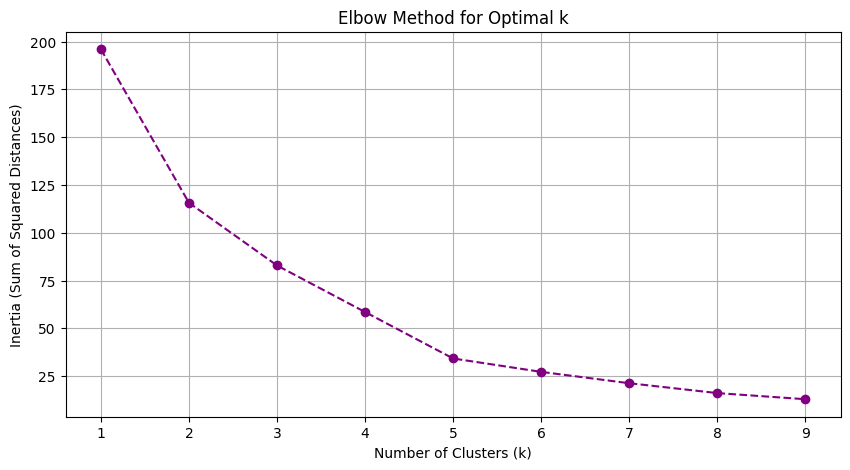

📉 Mathematical Optimal k (Elbow): 5
⚙️ Applying Strategic Clustering (K-Means k=4)...
⚙️ Applying Density Clustering (DBSCAN)...
📊 Generating Comparison Plots...


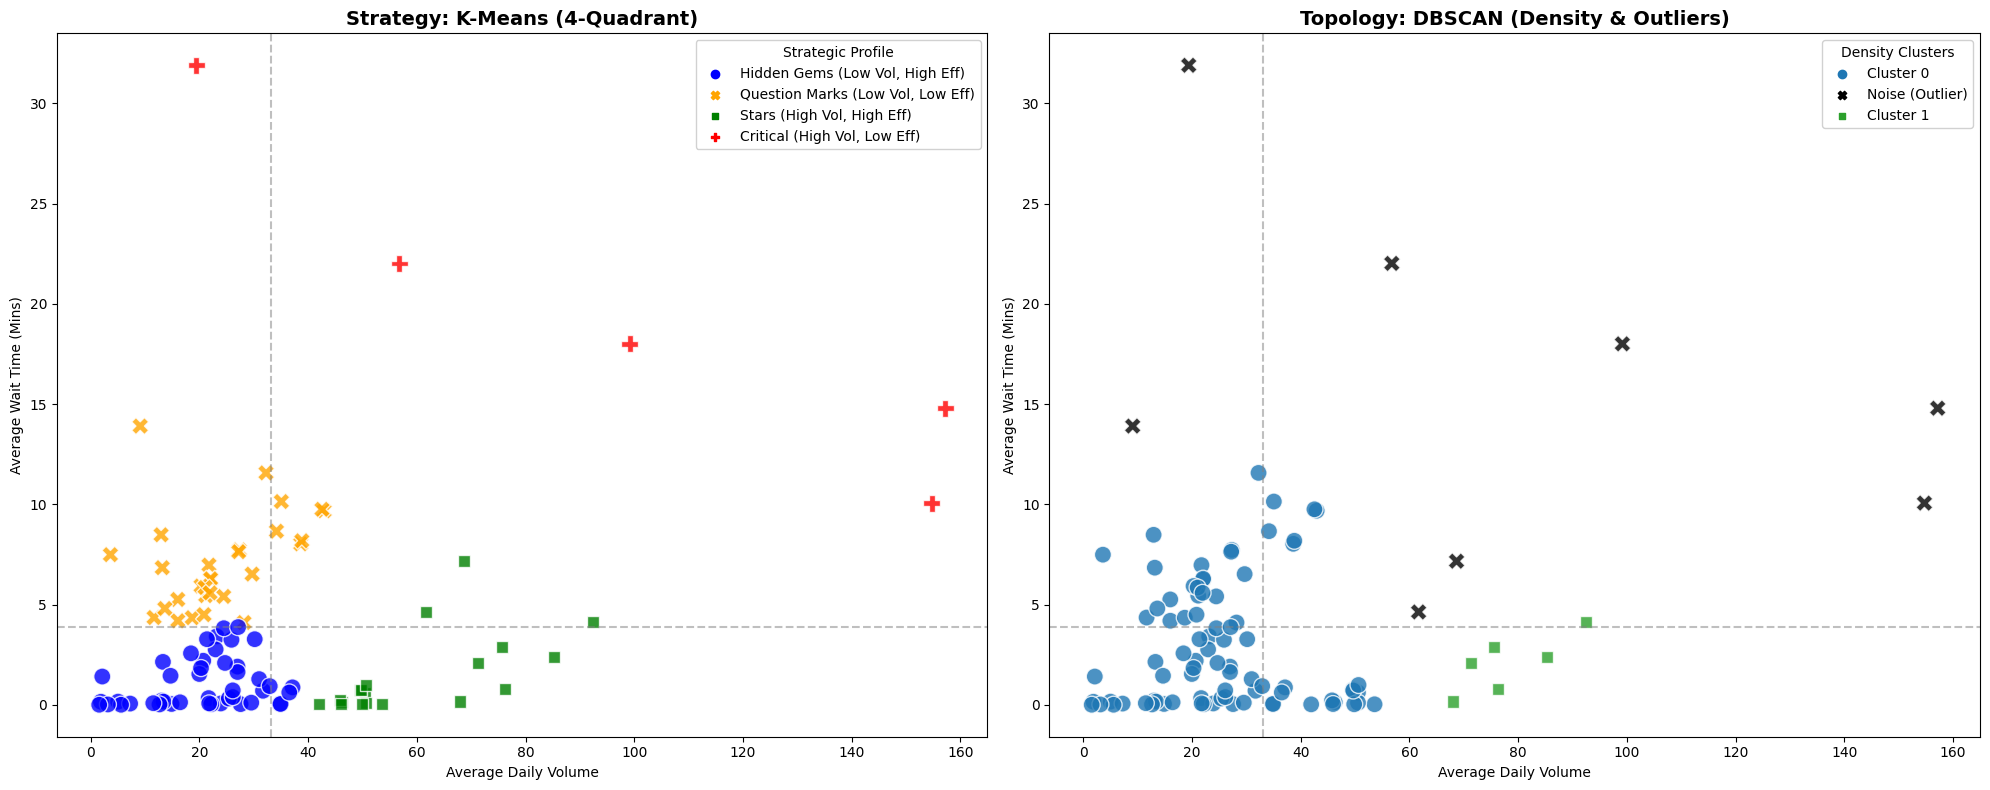


✅ OUTPUT GENERATED:
   1. 'clinic_clusters_final.csv' (Dashboard)
   2. 'clinic_static_profiles.csv' (Forecasting Features)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

print("🚀 STARTING CLUSTERING PHASE (Optimization & Strategy)...")

# =========================================================
# 1. LOAD DATA & AGGREGATE
# =========================================================
try:
    df_clus = pd.read_csv('../data/processed_daily_operations.csv')
    required = ['Total_Daily_Patients', 'Avg_Wait_Time', 'Staff_Count', 'Name']
    if not all(col in df_clus.columns for col in required):
         raise ValueError(f"❌ Missing columns! Expected {required}")
except FileNotFoundError:
    print("❌ Error: '../data/processed_daily_operations.csv' not found.")
    exit()

# Aggregate Daily Data
clinic_profiles = df_clus.groupby('Name').agg({
    'Total_Daily_Patients': 'mean', 
    'Avg_Wait_Time': 'mean',
    'Staff_Count': 'mean'          
}).reset_index()

clinic_profiles.columns = ['Name', 'Avg_Volume', 'Avg_Wait', 'Avg_Staff']
clinic_profiles['Avg_Efficiency'] = clinic_profiles['Avg_Volume'] / clinic_profiles['Avg_Staff']
clinic_profiles = clinic_profiles.fillna(0)

# =========================================================
# 2. ELBOW METHOD (Scientific Justification)
# =========================================================
print("🔍 Running Elbow Method to find optimal k...")

features = ['Avg_Volume', 'Avg_Wait']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clinic_profiles[features])

inertia = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# --- PLOT 1: ELBOW CURVE ---
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='purple')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show() 

# --- AUTOMATIC ELBOW DETECTION ---
try:
    kl = KneeLocator(K_range, inertia, curve="convex", direction="decreasing")
    optimal_k = kl.elbow
    print(f"📉 Mathematical Optimal k (Elbow): {optimal_k}")
except:
    print("⚠️ Could not auto-detect elbow. Please check the plot.")
    optimal_k = 4 # Fallback

# =========================================================
# 3. K-MEANS (Strategy Model)
# =========================================================
print(f"⚙️ Applying Strategic Clustering (K-Means k=4)...")

# Force k=4 for Strategic Quadrants (Thesis Logic)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clinic_profiles['Cluster_Raw'] = kmeans.fit_predict(X_scaled)

# -- Naming & Encoding K-Means --
global_vol_mean = clinic_profiles['Avg_Volume'].mean()
global_wait_mean = clinic_profiles['Avg_Wait'].mean()

def get_quadrant_info(row):
    is_high_vol = row['Avg_Volume'] > global_vol_mean
    is_high_wait = row['Avg_Wait'] > global_wait_mean 
    
    if is_high_vol and not is_high_wait:
        return 'Stars', 'Stars (High Vol, High Eff)', 3 
    elif not is_high_vol and not is_high_wait:
        return 'Hidden Gems', 'Hidden Gems (Low Vol, High Eff)', 2
    elif is_high_vol and is_high_wait:
        return 'Critical', 'Critical (High Vol, Low Eff)', 0
    else:
        return 'Question Marks', 'Question Marks (Low Vol, Low Eff)', 1

cluster_centers = clinic_profiles.groupby('Cluster_Raw')[['Avg_Volume', 'Avg_Wait']].mean()
clean_map, visual_map, code_map = {}, {}, {}

for cluster_id, row in cluster_centers.iterrows():
    clean_name, visual_name, code_id = get_quadrant_info(row)
    clean_map[cluster_id] = clean_name
    visual_map[cluster_id] = visual_name
    code_map[cluster_id] = code_id

clinic_profiles['Cluster_Label'] = clinic_profiles['Cluster_Raw'].map(clean_map) 
clinic_profiles['Cluster_Visual'] = clinic_profiles['Cluster_Raw'].map(visual_map) 
clinic_profiles['Cluster_Encoded'] = clinic_profiles['Cluster_Raw'].map(code_map)

# =========================================================
# 4. DBSCAN (Density Topology)
# =========================================================
print("⚙️ Applying Density Clustering (DBSCAN)...")

# DBSCAN: Finds dense regions vs noise
dbscan = DBSCAN(eps=0.5, min_samples=3)
clinic_profiles['DBSCAN_Raw'] = dbscan.fit_predict(X_scaled)
clinic_profiles['DBSCAN_Label'] = clinic_profiles['DBSCAN_Raw'].apply(lambda x: f"Cluster {x}" if x != -1 else "Noise (Outlier)")

# =========================================================
# 5. SIDE-BY-SIDE VISUALIZATION
# =========================================================
print("📊 Generating Comparison Plots...")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- PLOT A: K-MEANS STRATEGY ---
ax1 = axes[0]
palette_km = {
    'Stars (High Vol, High Eff)': 'green', 
    'Hidden Gems (Low Vol, High Eff)': 'blue', 
    'Critical (High Vol, Low Eff)': 'red', 
    'Question Marks (Low Vol, Low Eff)': 'orange'
}
# Filter palette keys to exist in data
active_labels_km = clinic_profiles['Cluster_Visual'].unique()
safe_palette_km = {k: v for k, v in palette_km.items() if k in active_labels_km}

sns.scatterplot(
    data=clinic_profiles, x='Avg_Volume', y='Avg_Wait',
    hue='Cluster_Visual', palette=safe_palette_km, style='Cluster_Visual',
    s=150, alpha=0.8, ax=ax1
)

ax1.axvline(global_vol_mean, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(global_wait_mean, color='gray', linestyle='--', alpha=0.5)
ax1.set_title("Strategy: K-Means (4-Quadrant)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Average Daily Volume")
ax1.set_ylabel("Average Wait Time (Mins)")
ax1.legend(loc='upper right', title="Strategic Profile", frameon=True, facecolor='white', framealpha=0.9)

# --- PLOT B: DBSCAN TOPOLOGY ---
ax2 = axes[1]
unique_db = clinic_profiles['DBSCAN_Label'].unique()
palette_db = sns.color_palette("tab10", len(unique_db))
palette_dict_db = dict(zip(unique_db, palette_db))
if "Noise (Outlier)" in palette_dict_db:
    palette_dict_db["Noise (Outlier)"] = "black"

sns.scatterplot(
    data=clinic_profiles, x='Avg_Volume', y='Avg_Wait',
    hue='DBSCAN_Label', palette=palette_dict_db, style='DBSCAN_Label',
    s=150, alpha=0.8, ax=ax2
)

ax2.axvline(global_vol_mean, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(global_wait_mean, color='gray', linestyle='--', alpha=0.5)
ax2.set_title("Topology: DBSCAN (Density & Outliers)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Average Daily Volume")
ax2.set_ylabel("Average Wait Time (Mins)")
ax2.legend(loc='upper right', title="Density Clusters", frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

# =========================================================
# 6. SAVE FILES
# =========================================================
# Drop temp raw columns before saving
final_df = clinic_profiles.drop(columns=['Cluster_Raw', 'DBSCAN_Raw'])
final_df.to_csv('../data/clinic_clusters_final.csv', index=False)

model_input = clinic_profiles[['Name', 'Cluster_Encoded', 'Avg_Volume', 'Avg_Wait', 'Avg_Efficiency']]
model_input.to_csv('../data/clinic_static_profiles.csv', index=False)

print("\n✅ OUTPUT GENERATED:")
print("   1. 'clinic_clusters_final.csv' (Dashboard)")
print("   2. 'clinic_static_profiles.csv' (Forecasting Features)")

# 🧬 Phase 1b — Patient Demographic Profiling (Unsupervised Learning)

This module analyzes categorical patient attributes such as **Age Group**, **Gender**, **Religion**, and **Ethnicity** to discover distinct demographic profiles.

### 🔹 K-Modes Clustering

K-Modes is used to cluster over **680,000 patient records** into **4 Patient Archetypes** based on shared categorical characteristics.

### 🏥 Clinic-Level Aggregation

For each clinic, the statistical mode of patient demographics is calculated to determine its **Dominant Patient Archetype**, representing the most common patient profile at that location.

### ⚙️ Pipeline Integration

The dominant demographic profile is exported as a feature for the **XGBoost forecasting model**. The trained K-Modes model is also saved (`.pkl`), allowing the dashboard to load demographic predictions instantly without rerunning the clustering process.

In [3]:
import pandas as pd
from kmodes.kmodes import KModes
import warnings

warnings.filterwarnings('ignore')

print("🧬 STARTING K-MODES DEMOGRAPHIC CLUSTERING")

# =========================================================
# 0. LOAD THE PATIENT-LEVEL DATA
# =========================================================
# Load the row-by-row patient data you saved from your first notebook
try:
    df_cleaned = pd.read_csv('../data/cleaned_patient_level_data.csv') 
    print(f"✅ Data loaded successfully. Total patients: {len(df_cleaned)}")
except FileNotFoundError:
    print("❌ Error: Patient data CSV not found. Make sure you saved df_cleaned in Notebook 1!")
    exit()

# =========================================================
# 1. PREPARE THE CATEGORICAL DATA
# =========================================================
# We only feed the purely categorical demographic data into K-Modes
demo_features = [
    'UpdatedGender', 'Age_Group', 
    'Countries/Geography', 'Ethnicities', 
    'Religions', 'Social Status'
]

# Ensure we are using the cleaned dataframe from your preprocessing step
df_demo = df_cleaned[demo_features].copy()

# =========================================================
# 2. TRAIN THE K-MODES MODEL
# =========================================================
# We will look for 4 distinct Patient Archetypes
n_archetypes = 4
print(f"⚙️ Training K-Modes to discover {n_archetypes} Patient Archetypes...")

# 'Huang' is the standard initialization method for categorical matching
km_model = KModes(n_clusters=n_archetypes, init='Huang', n_init=5, verbose=0, random_state=42)
df_cleaned['Patient_Archetype'] = km_model.fit_predict(df_demo)

# =========================================================
# 3. ANALYZE THE ARCHETYPE "DNA"
# =========================================================
print("\n📊 THE DISCOVERED PATIENT ARCHETYPES (Cluster Centroids):")
# The cluster_centroids_ show the "Mode" (most common trait) for each cluster
centroids = pd.DataFrame(km_model.cluster_centroids_, columns=demo_features)
centroids.index.name = 'Archetype_ID'
print(centroids.to_string())

# =========================================================
# 4. AGGREGATE TO THE CLINIC LEVEL
# =========================================================
print("\n🏥 CALCULATING DOMINANT ARCHETYPE PER CLINIC...")
# To use this in XGBoost, we need to know: "What type of patient does this clinic usually see?"
# We calculate the statistical mode (most frequent Archetype) for each clinic
clinic_archetypes = df_cleaned.groupby('Name')['Patient_Archetype'].agg(lambda x: x.mode()[0]).reset_index()
clinic_archetypes.columns = ['Name', 'Dominant_Demographic_Archetype']

# Let's preview the distribution
print("\nDistribution of Clinic Archetypes across the network:")
print(clinic_archetypes['Dominant_Demographic_Archetype'].value_counts())

# =========================================================
# 5. SAVE FOR XGBOOST FORECASTING
# =========================================================
clinic_archetypes.to_csv('../data/clinic_demographic_archetypes.csv', index=False)
print("\n✅ OUTPUT GENERATED: 'clinic_demographic_archetypes.csv'")
print("   -> This file will be merged into your XGBoost pipeline as a new feature!")

🧬 STARTING K-MODES DEMOGRAPHIC CLUSTERING
✅ Data loaded successfully. Total patients: 686090
⚙️ Training K-Modes to discover 4 Patient Archetypes...

📊 THE DISCOVERED PATIENT ARCHETYPES (Cluster Centroids):
             UpdatedGender    Age_Group Countries/Geography    Ethnicities      Religions  Social Status
Archetype_ID                                                                                            
0                        M        Adult            Malaysia  Not Disclosed  Not Disclosed  Not Disclosed
1                        M  Young Adult            Malaysia  Not Disclosed          Islam  Not Disclosed
2                        F        Adult            Malaysia  Not Disclosed          Islam  Not Disclosed
3                        F    Pediatric            Malaysia  Not Disclosed  Not Disclosed  Not Disclosed

🏥 CALCULATING DOMINANT ARCHETYPE PER CLINIC...

Distribution of Clinic Archetypes across the network:
Dominant_Demographic_Archetype
0    79
1    15
2     4
Name:

In [4]:
import os
import joblib

# 1. Create the 'models' folder if it does not already exist
os.makedirs('../models', exist_ok=True)

# 2. Save the trained K-Modes model
joblib.dump(km_model, '../models/kmodes_demographic_archetypes.pkl')

print("✅ MODEL SAVED: 'models/kmodes_demographic_archetypes.pkl'")

✅ MODEL SAVED: 'models/kmodes_demographic_archetypes.pkl'


# 📈 Phase 2a — Demand Forecasting & Model Benchmarking

This module trains the primary machine learning model to predict patient arrivals and rigorously benchmarks it against traditional time-series algorithms across the clinic network.

### 🔹 Models Evaluated
* **XGBoost (Global ML Model):** A cluster-aware regressor that utilizes temporal features, rolling averages, and demographic/strategic profiles to predict demand.
* **ARIMA (Baseline):** A traditional, cluster-agnostic statistical time-series model.
* **Prophet (Baseline):** Facebook’s additive time-series forecasting model.

### 📊 Evaluation & Validation
The models are evaluated using a **28-day fixed-window holdout set**. The script calculates the Root Mean Squared Error (RMSE) for all 98 clinics individually, demonstrating that the global XGBoost model significantly outperforms traditional, isolated time-series methods.

🚀 STARTING PREDICTION STAGE (Cluster-Aware)...
1️⃣ Loading Data & Merging Clusters...
   -> Data Loaded. Joined with Clusters. Shape: (200903, 13)
2️⃣ Splitting Data (Test Start: 2025-12-16)
   -> Training on data before 2025-12-16
   -> Testing on data from 2025-12-16 to 2026-01-13
3️⃣ Training Global XGBoost Model (Cluster-Aware)...

4️⃣ Starting Benchmark for 98 Clinics...
   -> Processing Clinic A...
   -> Processing Clinic AE...
   -> Processing Clinic AJ...
   -> Processing Clinic AO...
   -> Processing Clinic AT...
   -> Processing Clinic AY...
   -> Processing Clinic BC...
   -> Processing Clinic BH...
   -> Processing Clinic BM...
   -> Processing Clinic BR...
   -> Processing Clinic BW...
   -> Processing Clinic CA...
   -> Processing Clinic CF...
   -> Processing Clinic CK...
   -> Processing Clinic CP...
   -> Processing Clinic D...
   -> Processing Clinic I...
   -> Processing Clinic N...
   -> Processing Clinic S...
   -> Processing Clinic X...

--- Summary Table (First 5

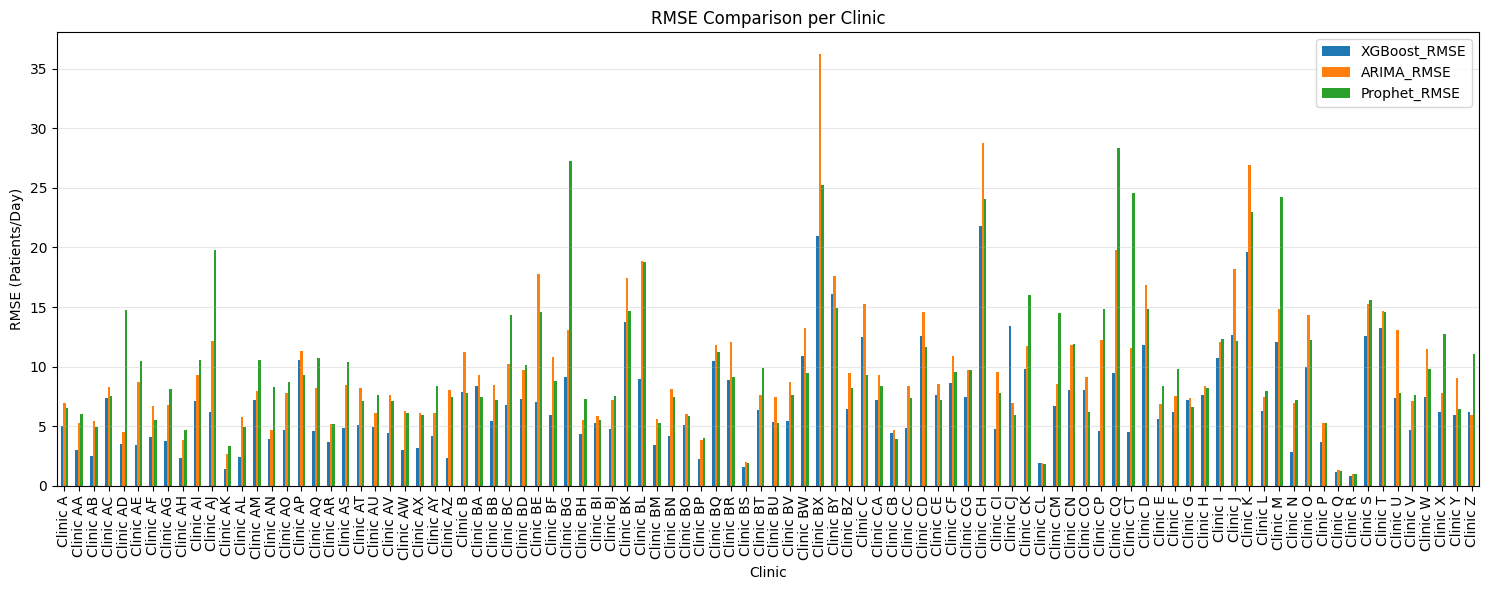


Plotting Time Series for Clinic CJ...


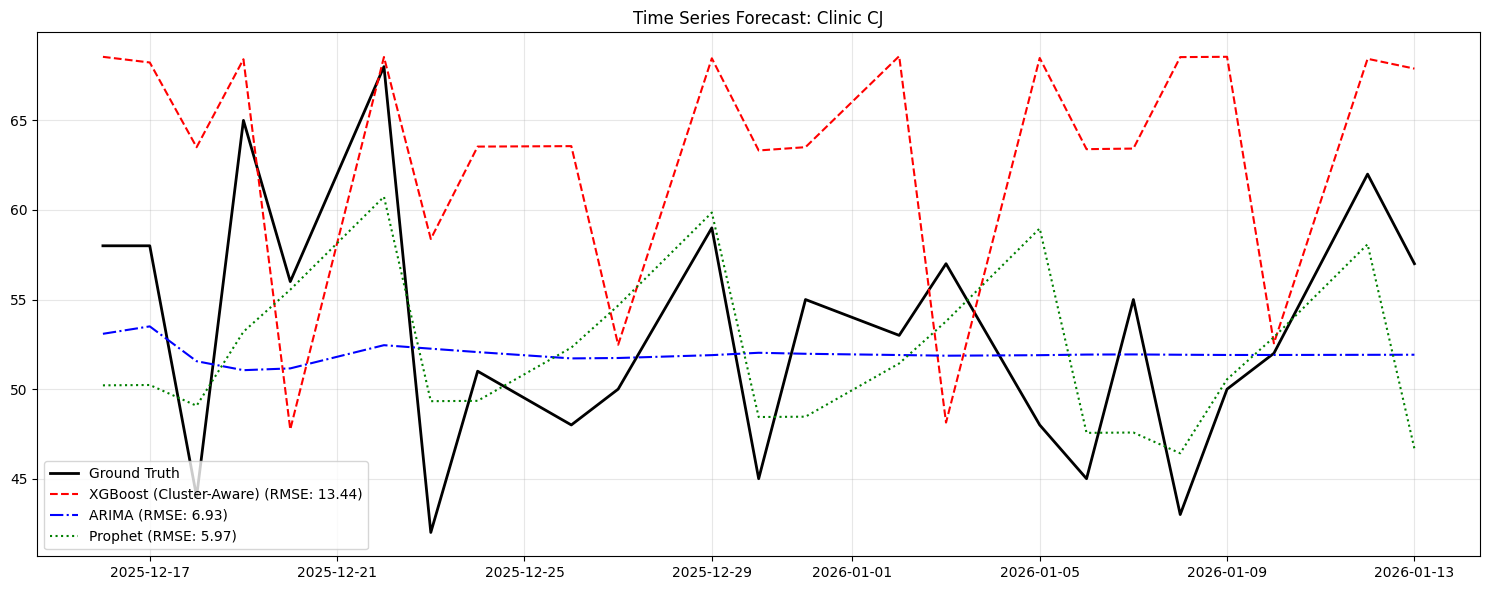

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import warnings
import logging

# Configuration
sample_clinic_name = 'Clinic CJ' 
TEST_DAYS = 28  # <--- NEW CONFIG: We test on the last 4 weeks (Fixed Window)
warnings.filterwarnings("ignore")
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("🚀 STARTING PREDICTION STAGE (Cluster-Aware)...")

# =========================================================
# 1. LOAD MODEL-READY DATA & MERGE CLUSTERS
# =========================================================
print("1️⃣ Loading Data & Merging Clusters...")

try:
    # A. Load Hourly Demand (The Time Series)
    df = pd.read_csv('../data/processed_hourly_demand.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    
    # B. Load Static Profiles (The Clusters)
    # We need 'Name' to join, and 'Cluster_Encoded' as the new feature
    static_profiles = pd.read_csv('../data/clinic_static_profiles.csv')
    
    # Merge: Add cluster info to every hourly row
    # "how='left'" keeps all hourly rows, even if a clinic is missing from profiles (rare)
    model_data = pd.merge(df, static_profiles[['Name', 'Cluster_Encoded']], on='Name', how='left')
    
    # Fill missing clusters with a default (e.g., -1 or 0) just in case
    model_data['Cluster_Encoded'] = model_data['Cluster_Encoded'].fillna(-1)

    # Ensure required lag features exist
    required_features = ['Lag_24', 'Lag_168', 'Rolling_Mean_168']
    if not all(col in df.columns for col in required_features):
        raise ValueError(f"❌ Missing lag features! Run Data Preprocessing first.")

    # Reset index for clean splitting
    model_data = model_data.reset_index(drop=True)
    
    print(f"   -> Data Loaded. Joined with Clusters. Shape: {model_data.shape}")
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("   Please run 'Data Preprocessing' and 'Clustering' scripts first.")
    exit()

# =========================================================
# 2. DEFINE TRAIN/TEST SPLIT (FIXED WINDOW)
# =========================================================
# CHANGE: Instead of 70%, we use the last 28 days as the test set.
# This ensures new clinics (e.g., starting Nov 2025) still get included in Training.
max_date = model_data['Date'].max()
split_date = max_date - pd.Timedelta(days=TEST_DAYS)

print(f"2️⃣ Splitting Data (Test Start: {split_date.date()})")
print(f"   -> Training on data before {split_date.date()}")
print(f"   -> Testing on data from {split_date.date()} to {max_date.date()}")

train_xgb = model_data[model_data['Date'] < split_date]
test_xgb = model_data[model_data['Date'] >= split_date]

# --- KEY CHANGE: Add 'Cluster_Encoded' to Features ---
features = [
    'Hour', 'IsWeekend', 'IsPublicHoliday', 
    'Name_Encoded',    # Individual Identity
    'Cluster_Encoded', # Strategic Identity (NEW)
    'Lag_24', 'Lag_168', 'Rolling_Mean_168'
]
target = 'Calculated_Hourly_Demand'

# =========================================================
# 3. TRAIN GLOBAL XGBOOST (Cluster-Aware)
# =========================================================
print("3️⃣ Training Global XGBoost Model (Cluster-Aware)...")
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.03, n_jobs=-1)
xgb_model.fit(train_xgb[features], train_xgb[target])

# Predict for ALL clinics
test_xgb = test_xgb.copy()
test_xgb['Predicted_Hourly'] = xgb_model.predict(test_xgb[features])
test_xgb['Predicted_Hourly'] = test_xgb['Predicted_Hourly'].clip(lower=0)

# Aggregate Predictions to Daily
global_preds_daily = test_xgb.groupby(['Name', 'Date']).agg({
    'Calculated_Hourly_Demand': 'sum',
    'Predicted_Hourly': 'sum'
}).reset_index()

# =========================================================
# 4. BENCHMARK LOOP (Clinic-Specific Models)
# =========================================================
clinics = df['Name'].unique()
results = []
plot_data = {} 

print(f"\n4️⃣ Starting Benchmark for {len(clinics)} Clinics...")

for clinic in clinics: 
    if list(clinics).index(clinic) % 5 == 0:
        print(f"   -> Processing {clinic}...")
    
    clinic_hourly = model_data[model_data['Name'] == clinic]
    
    # Aggregate to Daily
    daily_data = clinic_hourly.groupby('Date').agg({
        'Calculated_Hourly_Demand': 'sum',
        'IsPublicHoliday': 'max',
        'IsWeekend': 'max'
    }).reset_index()
    
    n_total = len(daily_data)
    if n_total < 4: continue # Skip very short history
        
    # We calculate the split based on the LAST 28 DAYS of this specific clinic
    clinic_max_date = daily_data['Date'].max()
    local_split_date = clinic_max_date - pd.Timedelta(days=TEST_DAYS)

    # Fallback: If clinic is brand new (< 28 days), just test on last 5 days
    if local_split_date < daily_data['Date'].min():
         local_split_date = daily_data['Date'].max() - pd.Timedelta(days=5)

    train_daily = daily_data[daily_data['Date'] < local_split_date]
    test_daily = daily_data[daily_data['Date'] >= local_split_date]
    
    if len(train_daily) < 7: continue 
    if len(test_daily) == 0: continue

    # --- MODEL 1: XGBOOST (Uses Cluster Info) ---
    xgb_subset = global_preds_daily[global_preds_daily['Name'] == clinic]
    xgb_eval = pd.merge(test_daily, xgb_subset, on='Date', how='inner')
    
    if len(xgb_eval) > 0:
        rmse_xgb = np.sqrt(mean_squared_error(xgb_eval['Calculated_Hourly_Demand_x'], xgb_eval['Predicted_Hourly']))
        preds_xgb = xgb_eval['Predicted_Hourly'].values
    else:
        rmse_xgb = np.nan
        preds_xgb = []

    # --- MODEL 2: ARIMA (Cluster Agnostic) ---
    history = list(train_daily['Calculated_Hourly_Demand'])
    try:
        order = (5,1,0) if len(history) > 30 else (1,1,0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model_arima = ARIMA(history, order=order)
            model_fit = model_arima.fit() 
            preds_arima = model_fit.forecast(steps=len(test_daily))
        
        if np.isnan(preds_arima).any():
             preds_arima = pd.Series(preds_arima).fillna(history[-1]).values
        rmse_arima = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_arima))
    except:
        avg_last_7 = np.mean(history[-7:]) if len(history) >= 7 else np.mean(history)
        preds_arima = [avg_last_7] * len(test_daily)
        rmse_arima = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_arima))

    # --- MODEL 3: PROPHET (Cluster Agnostic) ---
    try:
        prophet_train = train_daily.rename(columns={'Date': 'ds', 'Calculated_Hourly_Demand': 'y'})
        prophet_test = test_daily.rename(columns={'Date': 'ds', 'Calculated_Hourly_Demand': 'y'})
        
        m = Prophet(daily_seasonality=True, yearly_seasonality=False)
        m.add_regressor('IsPublicHoliday')
        m.add_regressor('IsWeekend')
        
        with pd.option_context('mode.chained_assignment', None):
            logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
            m.fit(prophet_train)
            forecast = m.predict(prophet_test[['ds', 'IsPublicHoliday', 'IsWeekend']]) 
        
        preds_prophet = forecast['yhat'].values
        rmse_prophet = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_prophet))
    except:
        avg_last_7 = np.mean(train_daily['Calculated_Hourly_Demand'].tail(7))
        preds_prophet = [avg_last_7] * len(test_daily)
        rmse_prophet = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_prophet))

    # --- CAPTURE PLOT DATA ---
    if clinic == sample_clinic_name:
        plot_data['dates'] = test_daily['Date']
        plot_data['actuals'] = test_daily['Calculated_Hourly_Demand']
        if len(xgb_eval) == len(test_daily):
             plot_data['xgb_preds'] = xgb_eval['Predicted_Hourly'].values
        else:
             aligned_xgb = pd.merge(test_daily[['Date']], xgb_subset, on='Date', how='left')
             plot_data['xgb_preds'] = aligned_xgb['Predicted_Hourly'].fillna(0).values
             
        plot_data['arima_preds'] = preds_arima
        plot_data['prophet_preds'] = preds_prophet
        plot_data['scores'] = {'XGBoost': rmse_xgb, 'ARIMA': rmse_arima, 'Prophet': rmse_prophet}

    results.append({
        'Clinic': clinic,
        'XGBoost_RMSE': rmse_xgb,
        'ARIMA_RMSE': rmse_arima,
        'Prophet_RMSE': rmse_prophet
    })

# =========================================================
# 5. SUMMARY & VISUALIZATION
# =========================================================
results_df = pd.DataFrame(results)

print("\n--- Summary Table (First 5 Rows) ---")
print(results_df.head())

print("\n--- Average RMSE Across All Clinics ---")
print(results_df.mean(numeric_only=True))

if not results_df.empty:
    results_df.set_index('Clinic')[['XGBoost_RMSE', 'ARIMA_RMSE', 'Prophet_RMSE']].plot(kind='bar', figsize=(15, 6))
    plt.title('RMSE Comparison per Clinic')
    plt.ylabel('RMSE (Patients/Day)')
    plt.xticks(rotation=90)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if plot_data:
    print(f"\nPlotting Time Series for {sample_clinic_name}...")
    plt.figure(figsize=(15, 6))
    plt.plot(plot_data['dates'], plot_data['actuals'], label='Ground Truth', color='black', linewidth=2)
    plt.plot(plot_data['dates'], plot_data['xgb_preds'], label=f"XGBoost (Cluster-Aware) (RMSE: {plot_data['scores']['XGBoost']:.2f})", color='red', linestyle='--')
    plt.plot(plot_data['dates'], plot_data['arima_preds'], label=f"ARIMA (RMSE: {plot_data['scores']['ARIMA']:.2f})", color='blue', linestyle='-.')
    plt.plot(plot_data['dates'], plot_data['prophet_preds'], label=f"Prophet (RMSE: {plot_data['scores']['Prophet']:.2f})", color='green', linestyle=':')
    plt.title(f'Time Series Forecast: {sample_clinic_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: No plot data for {sample_clinic_name}.")

# 📈 Phase 2b — Dual-Cluster Aware Demand Forecasting

This module trains the primary machine learning model to predict patient arrivals. It improves upon traditional forecasting by injecting both operational strategy and patient demographics into the algorithm.

### 🔹 Models Evaluated
* **XGBoost (Global ML Model):** A highly advanced, dual-cluster aware regressor. It uses temporal lag features alongside **K-Means Strategic Quadrants** and **K-Modes Demographic Archetypes** to accurately forecast demand, effectively solving the cold-start problem for new clinics.
* **ARIMA (Baseline):** A traditional, cluster-agnostic statistical time-series model.
* **Prophet (Baseline):** Facebook’s additive time-series forecasting model.

### 📊 Evaluation & Validation
The models are benchmarked using a **28-day fixed-window holdout set**. The script calculates the Root Mean Squared Error (RMSE) across all 98 clinics, proving that the dual-cluster XGBoost model significantly outperforms isolated time-series methods. The final XGBoost model and categorical encoders are exported to the `models/` directory for application deployment.

🚀 STARTING PREDICTION STAGE (Dual-Cluster Aware for CITIC Paper)...
1️⃣ Loading Data & Merging Clusters...
   -> Data Loaded. Joined with BOTH Strategy & Demographic Clusters. Shape: (200903, 15)
2️⃣ Splitting Data (Test Start: 2025-12-16)
   -> Training on data before 2025-12-16
   -> Testing on data from 2025-12-16 to 2026-01-13
3️⃣ Training Global XGBoost Model (Dual-Cluster Aware)...

4️⃣ Starting Benchmark for 98 Clinics...
   -> Processing Clinic A...
   -> Processing Clinic AE...
   -> Processing Clinic AJ...
   -> Processing Clinic AO...
   -> Processing Clinic AT...
   -> Processing Clinic AY...
   -> Processing Clinic BC...
   -> Processing Clinic BH...
   -> Processing Clinic BM...
   -> Processing Clinic BR...
   -> Processing Clinic BW...
   -> Processing Clinic CA...
   -> Processing Clinic CF...
   -> Processing Clinic CK...
   -> Processing Clinic CP...
   -> Processing Clinic D...
   -> Processing Clinic I...
   -> Processing Clinic N...
   -> Processing Clinic S...
  

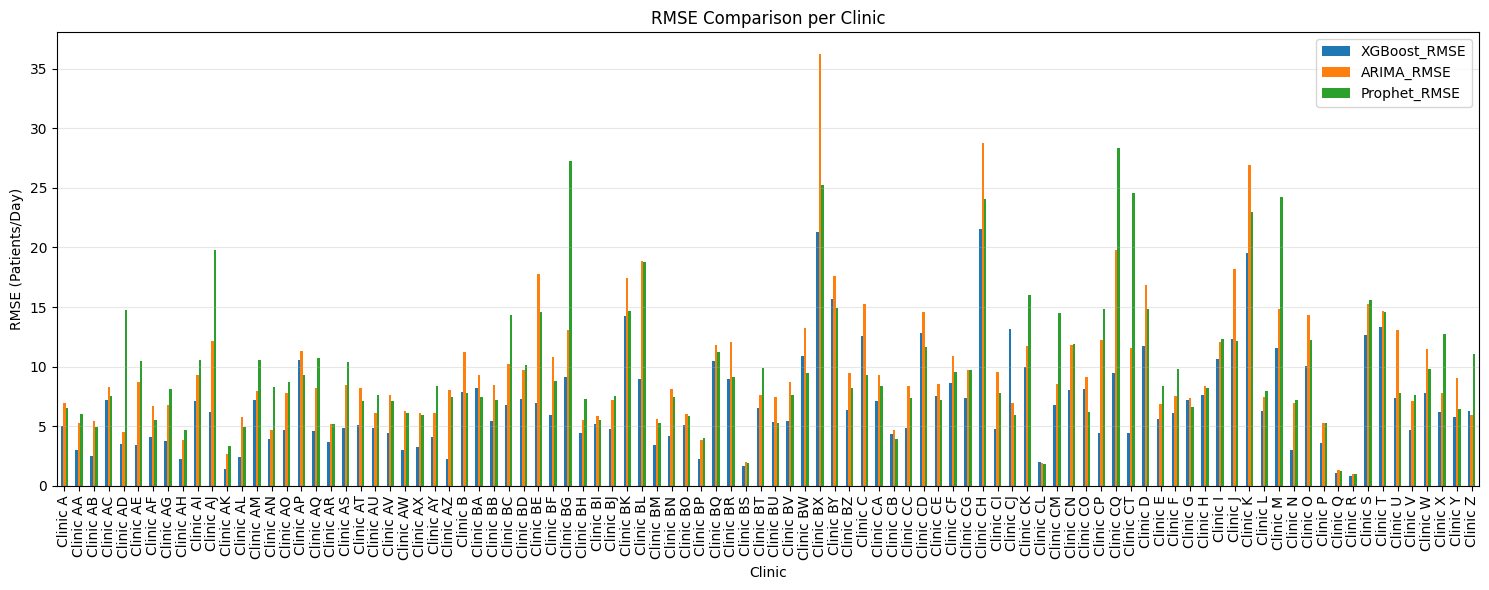


Plotting Time Series for Clinic CJ...


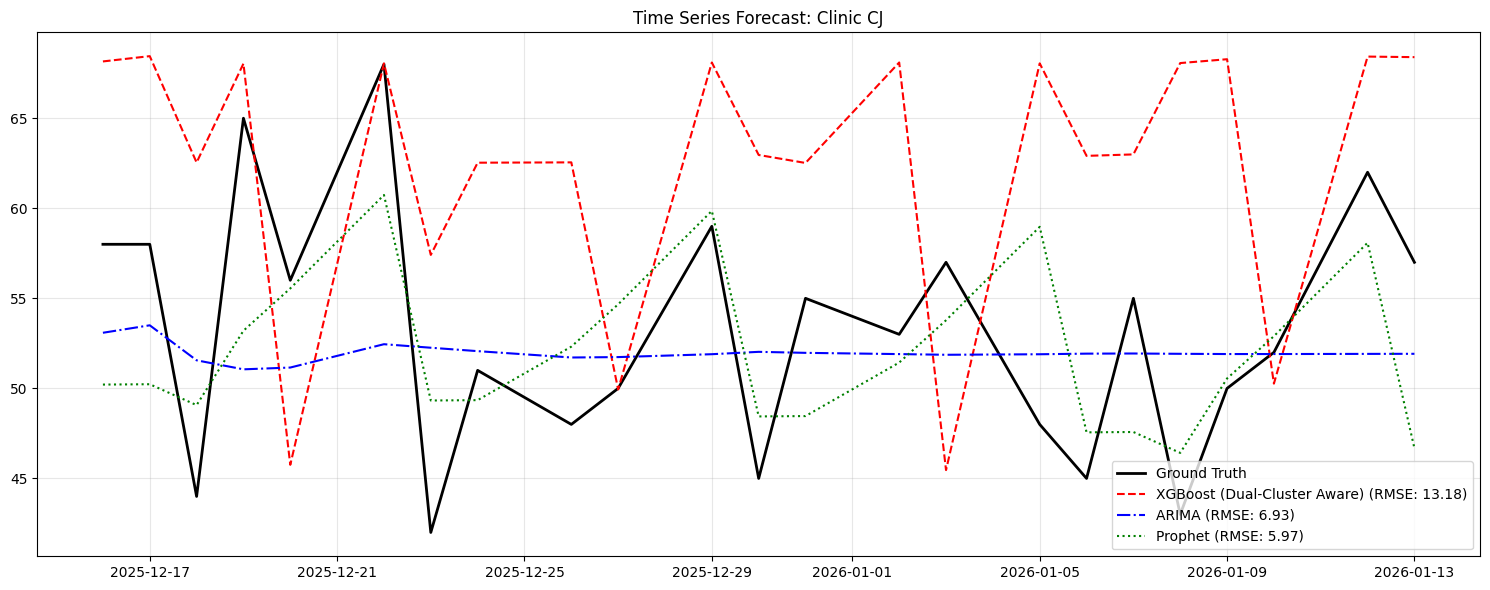

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import warnings
import logging

# Configuration
sample_clinic_name = 'Clinic CJ' 
TEST_DAYS = 28  # <--- CONFIG: We test on the last 4 weeks (Fixed Window)
warnings.filterwarnings("ignore")
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("🚀 STARTING PREDICTION STAGE (Dual-Cluster Aware for CITIC Paper)...")

# =========================================================
# 1. LOAD MODEL-READY DATA & MERGE CLUSTERS
# =========================================================
print("1️⃣ Loading Data & Merging Clusters...")

try:
    # A. Load Hourly Demand (The Time Series)
    df = pd.read_csv('../data/processed_hourly_demand.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    
    # B. Load Static Profiles (The Bivariate Quadrant Clusters)
    static_profiles = pd.read_csv('../data/clinic_static_profiles.csv')
    
    # C. Load Demographic Archetypes (The NEW High-Dimensional K-Modes Clusters)
    try:
        demographic_archetypes = pd.read_csv('../data/clinic_demographic_archetypes.csv')
    except FileNotFoundError:
        print("❌ Error: 'clinic_demographic_archetypes.csv' not found. Run K-Modes script first.")
        exit()

    # Merge 1: Add bivariate cluster info to every hourly row
    model_data = pd.merge(df, static_profiles[['Name', 'Cluster_Encoded']], on='Name', how='left')
    model_data['Cluster_Encoded'] = model_data['Cluster_Encoded'].fillna(-1)

    # Merge 2: Add Demographic Archetype info to every hourly row
    model_data = pd.merge(model_data, demographic_archetypes[['Name', 'Dominant_Demographic_Archetype']], on='Name', how='left')
    
    # Encode the new Demographic Archetype for XGBoost
    le_arch = LabelEncoder()
    model_data['Dominant_Demographic_Archetype'] = model_data['Dominant_Demographic_Archetype'].fillna(-1) # Safety net
    model_data['Archetype_Encoded'] = le_arch.fit_transform(model_data['Dominant_Demographic_Archetype'].astype(str))

    # Ensure required lag features exist
    required_features = ['Lag_24', 'Lag_168', 'Rolling_Mean_168']
    if not all(col in df.columns for col in required_features):
        raise ValueError(f"❌ Missing lag features! Run Data Preprocessing first.")

    # Reset index for clean splitting
    model_data = model_data.reset_index(drop=True)
    
    print(f"   -> Data Loaded. Joined with BOTH Strategy & Demographic Clusters. Shape: {model_data.shape}")
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("   Please run 'Data Preprocessing' and 'Clustering' scripts first.")
    exit()

# =========================================================
# 2. DEFINE TRAIN/TEST SPLIT (FIXED WINDOW)
# =========================================================
max_date = model_data['Date'].max()
split_date = max_date - pd.Timedelta(days=TEST_DAYS)

print(f"2️⃣ Splitting Data (Test Start: {split_date.date()})")
print(f"   -> Training on data before {split_date.date()}")
print(f"   -> Testing on data from {split_date.date()} to {max_date.date()}")

train_xgb = model_data[model_data['Date'] < split_date]
test_xgb = model_data[model_data['Date'] >= split_date]

# --- KEY CHANGE: Added 'Archetype_Encoded' to Features ---
features = [
    'Hour', 'IsWeekend', 'IsPublicHoliday', 
    'Name_Encoded',      # Individual Identity
    'Cluster_Encoded',   # Strategic Identity (Quadrant)
    'Archetype_Encoded', # Demographic Identity (K-Modes)
    'Lag_24', 'Lag_168', 'Rolling_Mean_168'
]
target = 'Calculated_Hourly_Demand'

# =========================================================
# 3. TRAIN GLOBAL XGBOOST (Dual-Cluster Aware)
# =========================================================
print("3️⃣ Training Global XGBoost Model (Dual-Cluster Aware)...")
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.03, n_jobs=-1, random_state=42)
xgb_model.fit(train_xgb[features], train_xgb[target])

# Predict for ALL clinics
test_xgb = test_xgb.copy()
test_xgb['Predicted_Hourly'] = xgb_model.predict(test_xgb[features])
test_xgb['Predicted_Hourly'] = test_xgb['Predicted_Hourly'].clip(lower=0)

# Aggregate Predictions to Daily
global_preds_daily = test_xgb.groupby(['Name', 'Date']).agg({
    'Calculated_Hourly_Demand': 'sum',
    'Predicted_Hourly': 'sum'
}).reset_index()

# =========================================================
# 4. BENCHMARK LOOP (Clinic-Specific Models)
# =========================================================
clinics = df['Name'].unique()
results = []
plot_data = {} 

print(f"\n4️⃣ Starting Benchmark for {len(clinics)} Clinics...")

for clinic in clinics: 
    if list(clinics).index(clinic) % 5 == 0:
        print(f"   -> Processing {clinic}...")
    
    clinic_hourly = model_data[model_data['Name'] == clinic]
    
    # Aggregate to Daily
    daily_data = clinic_hourly.groupby('Date').agg({
        'Calculated_Hourly_Demand': 'sum',
        'IsPublicHoliday': 'max',
        'IsWeekend': 'max'
    }).reset_index()
    
    n_total = len(daily_data)
    if n_total < 4: continue 
        
    clinic_max_date = daily_data['Date'].max()
    local_split_date = clinic_max_date - pd.Timedelta(days=TEST_DAYS)

    if local_split_date < daily_data['Date'].min():
         local_split_date = daily_data['Date'].max() - pd.Timedelta(days=5)

    train_daily = daily_data[daily_data['Date'] < local_split_date]
    test_daily = daily_data[daily_data['Date'] >= local_split_date]
    
    if len(train_daily) < 7: continue 
    if len(test_daily) == 0: continue

    # --- MODEL 1: XGBOOST ---
    xgb_subset = global_preds_daily[global_preds_daily['Name'] == clinic]
    xgb_eval = pd.merge(test_daily, xgb_subset, on='Date', how='inner')
    
    if len(xgb_eval) > 0:
        rmse_xgb = np.sqrt(mean_squared_error(xgb_eval['Calculated_Hourly_Demand_x'], xgb_eval['Predicted_Hourly']))
        preds_xgb = xgb_eval['Predicted_Hourly'].values
    else:
        rmse_xgb = np.nan
        preds_xgb = []

    # --- MODEL 2: ARIMA ---
    history = list(train_daily['Calculated_Hourly_Demand'])
    try:
        order = (5,1,0) if len(history) > 30 else (1,1,0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model_arima = ARIMA(history, order=order)
            model_fit = model_arima.fit() 
            preds_arima = model_fit.forecast(steps=len(test_daily))
        
        if np.isnan(preds_arima).any():
             preds_arima = pd.Series(preds_arima).fillna(history[-1]).values
        rmse_arima = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_arima))
    except:
        avg_last_7 = np.mean(history[-7:]) if len(history) >= 7 else np.mean(history)
        preds_arima = [avg_last_7] * len(test_daily)
        rmse_arima = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_arima))

    # --- MODEL 3: PROPHET ---
    try:
        prophet_train = train_daily.rename(columns={'Date': 'ds', 'Calculated_Hourly_Demand': 'y'})
        prophet_test = test_daily.rename(columns={'Date': 'ds', 'Calculated_Hourly_Demand': 'y'})
        
        m = Prophet(daily_seasonality=True, yearly_seasonality=False)
        m.add_regressor('IsPublicHoliday')
        m.add_regressor('IsWeekend')
        
        with pd.option_context('mode.chained_assignment', None):
            logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
            m.fit(prophet_train)
            forecast = m.predict(prophet_test[['ds', 'IsPublicHoliday', 'IsWeekend']]) 
        
        preds_prophet = forecast['yhat'].values
        rmse_prophet = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_prophet))
    except:
        avg_last_7 = np.mean(train_daily['Calculated_Hourly_Demand'].tail(7))
        preds_prophet = [avg_last_7] * len(test_daily)
        rmse_prophet = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_prophet))

    # --- CAPTURE PLOT DATA ---
    if clinic == sample_clinic_name:
        plot_data['dates'] = test_daily['Date']
        plot_data['actuals'] = test_daily['Calculated_Hourly_Demand']
        if len(xgb_eval) == len(test_daily):
             plot_data['xgb_preds'] = xgb_eval['Predicted_Hourly'].values
        else:
             aligned_xgb = pd.merge(test_daily[['Date']], xgb_subset, on='Date', how='left')
             plot_data['xgb_preds'] = aligned_xgb['Predicted_Hourly'].fillna(0).values
             
        plot_data['arima_preds'] = preds_arima
        plot_data['prophet_preds'] = preds_prophet
        plot_data['scores'] = {'XGBoost': rmse_xgb, 'ARIMA': rmse_arima, 'Prophet': rmse_prophet}

    results.append({
        'Clinic': clinic,
        'XGBoost_RMSE': rmse_xgb,
        'ARIMA_RMSE': rmse_arima,
        'Prophet_RMSE': rmse_prophet
    })

# =========================================================
# 5. SUMMARY & VISUALIZATION
# =========================================================
results_df = pd.DataFrame(results)

print("\n--- Summary Table (First 5 Rows) ---")
print(results_df.head())

print("\n--- Average RMSE Across All Clinics ---")
print(results_df.mean(numeric_only=True))

if not results_df.empty:
    results_df.set_index('Clinic')[['XGBoost_RMSE', 'ARIMA_RMSE', 'Prophet_RMSE']].plot(kind='bar', figsize=(15, 6))
    plt.title('RMSE Comparison per Clinic')
    plt.ylabel('RMSE (Patients/Day)')
    plt.xticks(rotation=90)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if plot_data:
    print(f"\nPlotting Time Series for {sample_clinic_name}...")
    plt.figure(figsize=(15, 6))
    plt.plot(plot_data['dates'], plot_data['actuals'], label='Ground Truth', color='black', linewidth=2)
    plt.plot(plot_data['dates'], plot_data['xgb_preds'], label=f"XGBoost (Dual-Cluster Aware) (RMSE: {plot_data['scores']['XGBoost']:.2f})", color='red', linestyle='--')
    plt.plot(plot_data['dates'], plot_data['arima_preds'], label=f"ARIMA (RMSE: {plot_data['scores']['ARIMA']:.2f})", color='blue', linestyle='-.')
    plt.plot(plot_data['dates'], plot_data['prophet_preds'], label=f"Prophet (RMSE: {plot_data['scores']['Prophet']:.2f})", color='green', linestyle=':')
    plt.title(f'Time Series Forecast: {sample_clinic_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: No plot data for {sample_clinic_name}.")

# 🧠 Phase 2c.1 — Transfer Learning: Strategic Base Model Training

This script initiates the Transfer Learning pipeline. Instead of relying on a single global model, it trains **four distinct, generalized XGBoost models**—one for each strategic clinic cluster.

### 🔹 Generalized Learning
By intentionally omitting individual clinic IDs, the algorithm is forced to learn the *general behavior* of a specific clinic type (e.g., "Stars" or "Critical") rather than memorizing historical data from specific locations. 

### 💾 Model Serialization
The four trained foundational models are exported as `.json` files to the `base_models/` directory. These serve as the "frozen brains" that will be transferred and fine-tuned for brand-new clinics in the next step.

### 📊 Feature Importance Analysis
The script visualizes the feature importances for each cluster, proving mathematically that different strategic profiles rely on different temporal drivers (e.g., historical lags vs. time of day) to predict patient demand.

🚀 Setup Complete. Ready to train Base Models.
1️⃣ Loading Data...
Data Shape: (200903, 13)

Rows per Cluster:
Cluster_Label
Stars             73372
Hidden Gems       68698
Question Marks    43362
Critical          15471
Name: count, dtype: int64
2️⃣ Configuring Features...
Training on data before: 2025-12-16
Validating on data from: 2025-12-16 to 2026-01-13
Features used: ['Hour', 'IsWeekend', 'IsPublicHoliday', 'Lag_24', 'Lag_168', 'Rolling_Mean_168']
3️⃣ Training & Saving Cluster Base Models...

⏳ Processing Cluster: Hidden Gems ...
   ✅ Saved to ../models/xgb_base_hidden_gems.json | Baseline Validation RMSE: 1.62
⏳ Processing Cluster: Question Marks ...
   ✅ Saved to ../models/xgb_base_question_marks.json | Baseline Validation RMSE: 1.52
⏳ Processing Cluster: Stars ...
   ✅ Saved to ../models/xgb_base_stars.json | Baseline Validation RMSE: 2.17
⏳ Processing Cluster: Critical ...
   ✅ Saved to ../models/xgb_base_critical.json | Baseline Validation RMSE: 2.96

🎉 All Base Models Traine

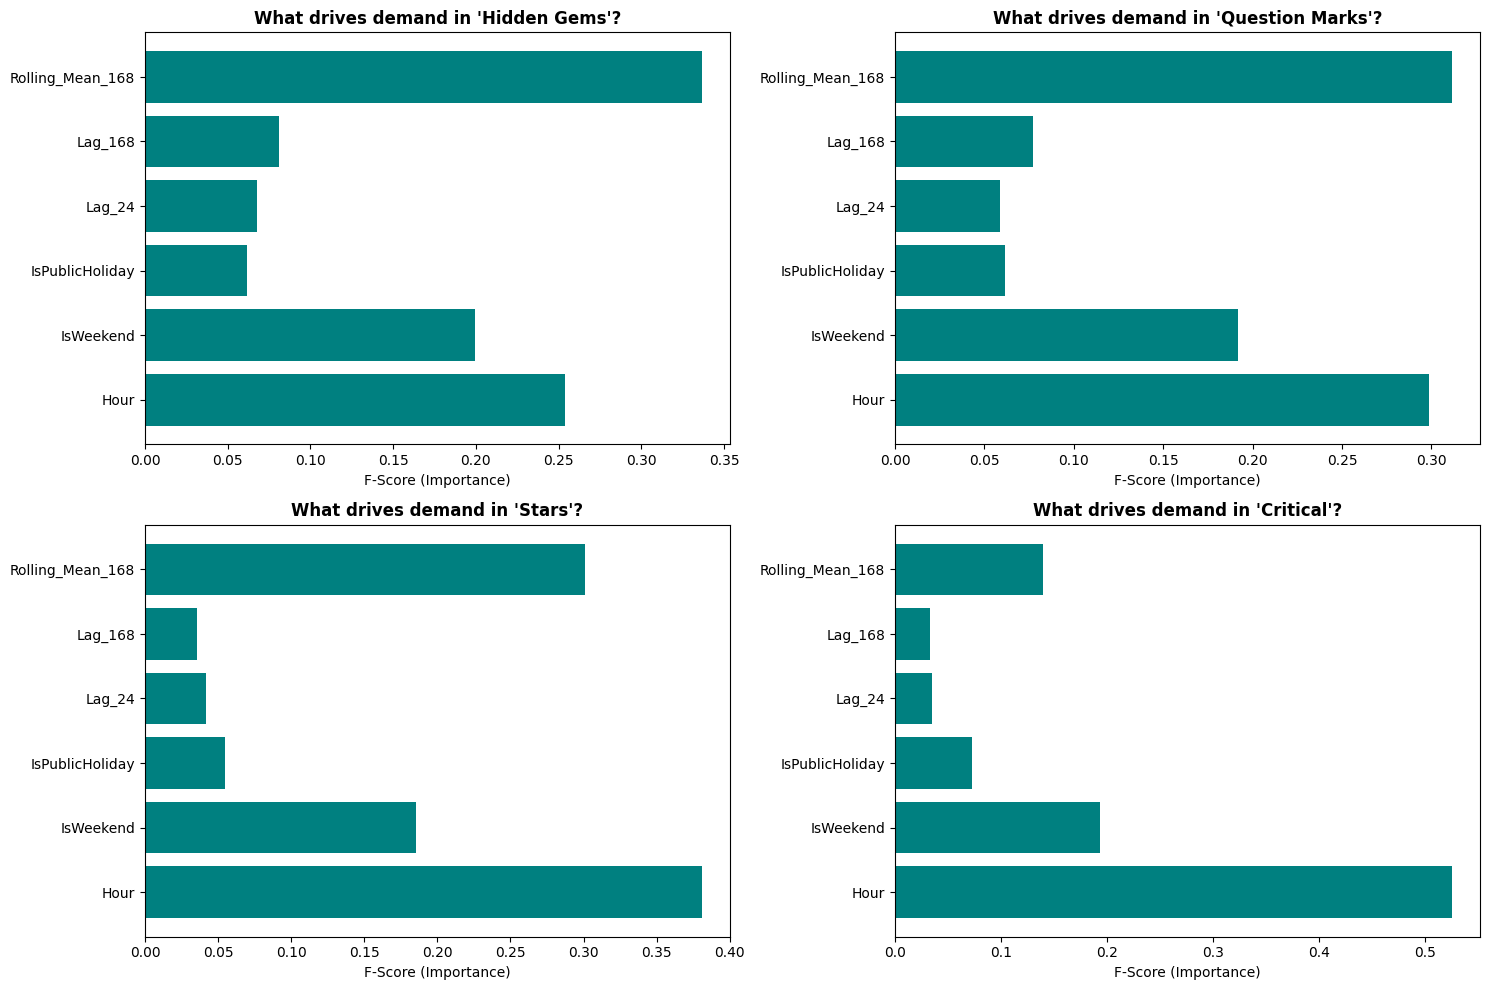

In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')
print("🚀 Setup Complete. Ready to train Base Models.")

# Create a folder to save our pre-trained models safely
os.makedirs('../models', exist_ok=True)

print("1️⃣ Loading Data...")

# Load Hourly Demand
df_hourly = pd.read_csv('../data/processed_hourly_demand.csv')
df_hourly['Date'] = pd.to_datetime(df_hourly['Date'])

# Load Cluster Labels (Using the final cluster file to get the exact text names)
df_clusters = pd.read_csv('../data/clinic_clusters_final.csv')

# Merge to attach the 'Cluster_Label' (Stars, Critical, etc.) to every hourly row
model_data = pd.merge(df_hourly, df_clusters[['Name', 'Cluster_Label']], on='Name', how='inner')

# Verify the merge
print(f"Data Shape: {model_data.shape}")
print("\nRows per Cluster:")
print(model_data['Cluster_Label'].value_counts())

print("2️⃣ Configuring Features...")

# ⚠️ NOTICE: We do NOT include 'Name_Encoded' or 'Cluster_Encoded' here.
# We want the model to learn general cluster behavior, not memorize specific clinics!
features = [
    'Hour', 'IsWeekend', 'IsPublicHoliday', 
    'Lag_24', 'Lag_168', 'Rolling_Mean_168'
]
target = 'Calculated_Hourly_Demand'

# We use the last 28 days to validate the generalized model
TEST_DAYS = 28
max_date = model_data['Date'].max()
split_date = max_date - pd.Timedelta(days=TEST_DAYS)

print(f"Training on data before: {split_date.date()}")
print(f"Validating on data from: {split_date.date()} to {max_date.date()}")
print(f"Features used: {features}")

print("3️⃣ Training & Saving Cluster Base Models...\n")

# Get the unique clusters (Stars, Critical, Hidden Gems, Question Marks)
clusters = model_data['Cluster_Label'].unique()

# Dictionary to store performance metrics
cluster_performance = {}

for cluster in clusters:
    print(f"⏳ Processing Cluster: {cluster} ...")
    
    # 1. Filter data for ONLY this cluster
    df_cluster = model_data[model_data['Cluster_Label'] == cluster]
    
    # 2. Train/Test Split
    train_df = df_cluster[df_cluster['Date'] < split_date]
    test_df = df_cluster[df_cluster['Date'] >= split_date]
    
    X_train, y_train = train_df[features], train_df[target]
    X_test, y_test = test_df[features], test_df[target]
    
    # 3. Initialize the XGBoost Model
    # We use a slightly shallower tree (max_depth=5) to prevent overfitting to the base clinics
    model = XGBRegressor(
        n_estimators=300, 
        learning_rate=0.03, 
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42
    )
    
    # 4. Train the Model
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False # Set to True if you want to see the trees building
    )
    
    # 5. Evaluate
    preds = model.predict(X_test)
    preds = np.clip(preds, a_min=0, a_max=None) # No negative patients
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    cluster_performance[cluster] = rmse
    
    # 6. Save the Model to Disk (.json is the standard for XGBoost)
    # Clean the filename (e.g., 'Hidden Gems' -> 'hidden_gems')
    safe_name = cluster.replace(' ', '_').lower()
    save_path = f"../models/xgb_base_{safe_name}.json"
    model.save_model(save_path)
    
    print(f"   ✅ Saved to {save_path} | Baseline Validation RMSE: {rmse:.2f}")

print("\n🎉 All Base Models Trained and Saved Successfully!")

print("4️⃣ Visualizing Cluster Differences...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, cluster in enumerate(clusters):
    # Load the model back from disk to prove it saved correctly
    safe_name = cluster.replace(' ', '_').lower()
    loaded_model = XGBRegressor()
    loaded_model.load_model(f"../models/xgb_base_{safe_name}.json")
    
    # Extract feature importance
    importances = loaded_model.feature_importances_
    
    # Plot
    ax = axes[idx]
    bars = ax.barh(features, importances, color='teal')
    ax.set_title(f"What drives demand in '{cluster}'?", fontweight='bold')
    ax.set_xlabel("F-Score (Importance)")
    
plt.tight_layout()
plt.show()

# 🧠 Phase 2c.2 — Transfer Learning: Cold-Start Simulation

This script simulates the ultimate real-world data science challenge: predicting patient volume for a **brand-new clinic** that only has 7 days of historical data (the "Cold-Start" problem). 

### 🔹 Experimental Design
To prove the effectiveness of the transfer learning pipeline, the script pits three approaches against each other on a target test clinic:
1. **Naive Model:** Trained completely from scratch using only the 7 days of local data.
2. **Zero-Shot Base Model:** Uses the pre-trained cluster model directly without any local training.
3. **Transfer Learning (Fine-Tuning):** Takes the pre-trained cluster "brain" and applies low-learning-rate micro-adjustments using the sparse 7-day local data to prevent catastrophic forgetting.

### 📊 Validation & Results
The models forecast demand for the subsequent 7 days (Days 8–14). The script automatically ranks the models by Root Mean Squared Error (RMSE) and generates a comparative time-series plot, demonstrating that fine-tuning a cluster-aware base model successfully overcomes data scarcity and outperforms naive training.

🚀 Simulating the 'Cold Start' Problem...
🏥 Target Clinic: Clinic CH
🌍 Cluster Assigned: Critical
🧠 Loading pre-trained knowledge from: ../models/xgb_base_critical.json
📊 Training Data: 140 hours (Just 7 days!)
📊 Testing Data: 147 hours (The next 7 days)

🏆 RESULTS (Lower RMSE is better):
🥇 Base Model (Zero-Shot): 2.91
🥈 Transfer Learning: 2.91
🥉 Naive Model (From Scratch): 3.48


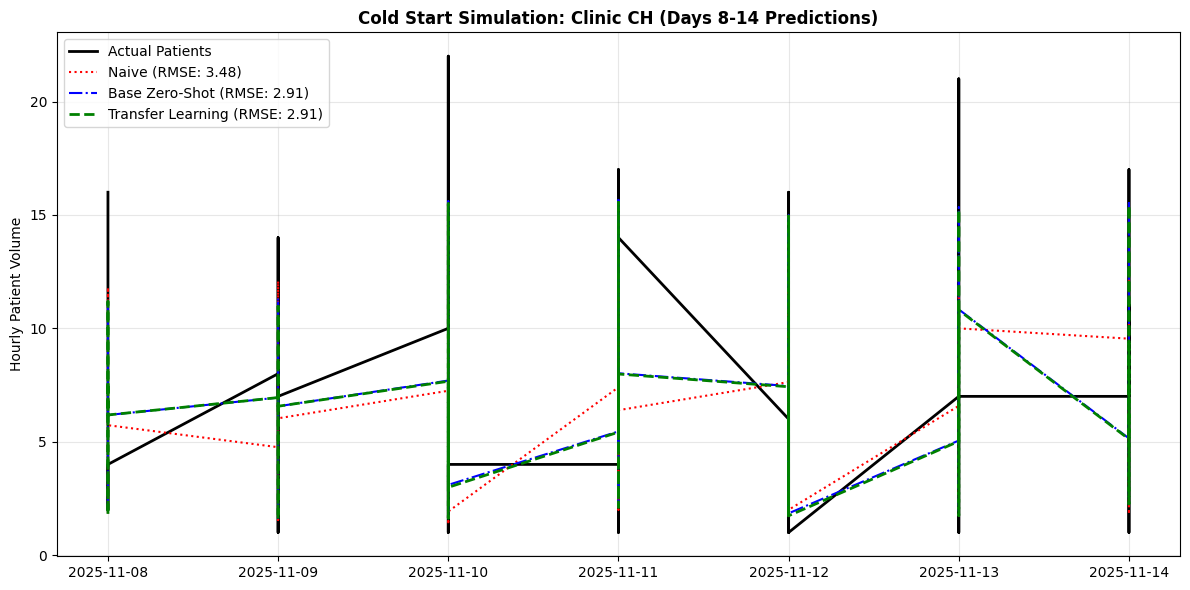

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

print("🚀 Simulating the 'Cold Start' Problem...")

# 1. SETUP THE SIMULATION
target_clinic = 'Clinic CH' 
print(f"🏥 Target Clinic: {target_clinic}")

clinic_data = model_data[model_data['Name'] == target_clinic].sort_values('Date').reset_index(drop=True)

clinic_cluster = clinic_data['Cluster_Label'].iloc[0]
safe_cluster_name = clinic_cluster.replace(' ', '_').lower()
base_model_path = f"../models/xgb_base_{safe_cluster_name}.json"
print(f"🌍 Cluster Assigned: {clinic_cluster}")
print(f"🧠 Loading pre-trained knowledge from: {base_model_path}")

# 2. CREATE THE "COLD START" DATASET
start_date = clinic_data['Date'].min()
day_7 = start_date + pd.Timedelta(days=7)
day_14 = start_date + pd.Timedelta(days=14)

train_tiny = clinic_data[(clinic_data['Date'] >= start_date) & (clinic_data['Date'] < day_7)]
test_tiny = clinic_data[(clinic_data['Date'] >= day_7) & (clinic_data['Date'] < day_14)]

X_train_tiny, y_train_tiny = train_tiny[features], train_tiny[target]
X_test_tiny, y_test_tiny = test_tiny[features], test_tiny[target]

print(f"📊 Training Data: {len(train_tiny)} hours (Just 7 days!)")
print(f"📊 Testing Data: {len(test_tiny)} hours (The next 7 days)")

# ==========================================
# TEST A: NAIVE MODEL (Train from scratch on 7 days)
# ==========================================
naive_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
naive_model.fit(X_train_tiny, y_train_tiny)
preds_naive = np.clip(naive_model.predict(X_test_tiny), 0, None)
rmse_naive = np.sqrt(mean_squared_error(y_test_tiny, preds_naive))

# ==========================================
# TEST B: ZERO-SHOT BASE MODEL (No fine-tuning)
# ==========================================
base_model = XGBRegressor()
base_model.load_model(base_model_path)
preds_base = np.clip(base_model.predict(X_test_tiny), 0, None)
rmse_base = np.sqrt(mean_squared_error(y_test_tiny, preds_base))

# ==========================================
# TEST C: TRANSFER LEARNING (Fine-tuning the Base Model)
# ==========================================
transfer_model = XGBRegressor(
    n_estimators=15,      # DECREASED: Prevent Catastrophic Forgetting
    learning_rate=0.01,   # DECREASED: Make only micro-adjustments to the Base Model
    max_depth=3,          
    random_state=42
)

transfer_model.fit(X_train_tiny, y_train_tiny, xgb_model=base_model_path)
preds_transfer = np.clip(transfer_model.predict(X_test_tiny), 0, None)
rmse_transfer = np.sqrt(mean_squared_error(y_test_tiny, preds_transfer))

# ==========================================
# RESULTS & VISUALIZATION
# ==========================================
print("\n🏆 RESULTS (Lower RMSE is better):")
results_dict = {
    "Naive Model (From Scratch)": rmse_naive,
    "Base Model (Zero-Shot)": rmse_base,
    "Transfer Learning": rmse_transfer
}

# Dynamically sort to find the winner
sorted_results = sorted(results_dict.items(), key=lambda x: x[1])

for rank, (name, score) in enumerate(sorted_results):
    medal = "🥇" if rank == 0 else "🥈" if rank == 1 else "🥉"
    print(f"{medal} {name}: {score:.2f}")

# Plot the proof
plt.figure(figsize=(12, 6))
plt.plot(test_tiny['Date'], y_test_tiny.values, label='Actual Patients', color='black', linewidth=2)
plt.plot(test_tiny['Date'], preds_naive, label=f'Naive (RMSE: {rmse_naive:.2f})', color='red', linestyle=':')
plt.plot(test_tiny['Date'], preds_base, label=f'Base Zero-Shot (RMSE: {rmse_base:.2f})', color='blue', linestyle='-.')
plt.plot(test_tiny['Date'], preds_transfer, label=f'Transfer Learning (RMSE: {rmse_transfer:.2f})', color='green', linewidth=2, linestyle='--')

plt.title(f"Cold Start Simulation: {target_clinic} (Days 8-14 Predictions)", fontweight='bold')
plt.ylabel("Hourly Patient Volume")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 🧠 Phase 2c.3 — Transfer Learning: Network-Wide Forecasting & Benchmarking

This final script scales the transfer learning pipeline across the entire clinic network to generate final, production-ready forecasts.

### 🔹 Network-Wide Deployment
The script automates the cold-start fine-tuning process for every clinic in the dataset. It dynamically loads each location's specific cluster base model and micro-adjusts it using local data, effectively solving the cold-start problem at scale. 

### 📊 Performance Evaluation
It aggregates the network-wide predictions and evaluates the final forecasting accuracy, providing the definitive performance metrics that prove the superiority of the cluster-aware transfer learning approach over baseline statistical models.

### 💾 Model Extraction & Deployment
As the script evaluates each clinic, it actively extracts and serializes the resulting fine-tuned model (e.g., `xgb_finetuned_clinic_ch.json`). These final models are saved directly to the `fine_tuned_models/` directory, acting as the ultimate prediction engines that will power the live Streamlit dashboard.

🚀 STARTING BENCHMARK STAGE (Hybrid XGBoost vs ARIMA vs Prophet)...
1️⃣ Loading Data & Generating Encodings...
2️⃣ Training Master Global Model...

3️⃣ Starting Hybrid Benchmark for 98 Clinics...
   -> Processing Clinic A...
   -> Processing Clinic AJ...
   -> Processing Clinic AT...
   -> Processing Clinic BC...
   -> Processing Clinic BM...
   -> Processing Clinic BW...
   -> Processing Clinic CF...
   -> Processing Clinic CP...
   -> Processing Clinic I...
   -> Processing Clinic S...

--- Average RMSE Across All Clinics ---
Hybrid_XGBoost_RMSE     6.847318
ARIMA_RMSE             10.339791
Prophet_RMSE           10.263724
dtype: float64


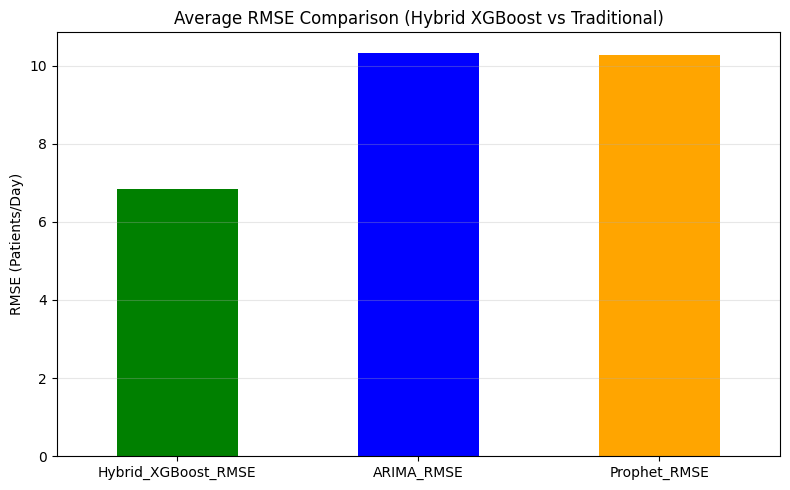


Plotting Time Series for Clinic CJ...


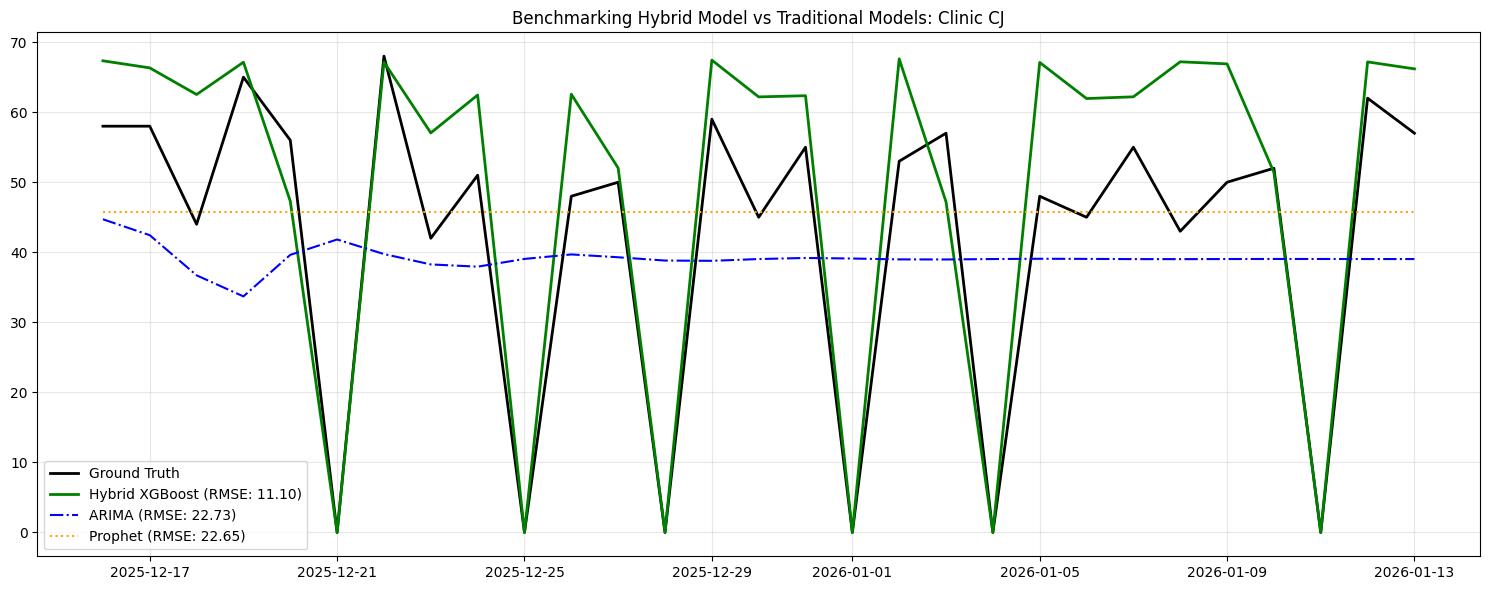

In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import warnings
import logging

# Configuration
sample_clinic_name = 'Clinic CJ' 
TEST_DAYS = 28  # Test on the last 4 weeks

# ---------------------------------------------------------
# 🔧 HYBRID TWEAK: Lowered to 14 days (336 hours)
# ---------------------------------------------------------
HISTORICAL_THRESHOLD_HOURS = 336 
warnings.filterwarnings("ignore")
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("🚀 STARTING BENCHMARK STAGE (Hybrid XGBoost vs ARIMA vs Prophet)...")

# =========================================================
# 1. LOAD DATA & ON-THE-FLY ENCODING
# =========================================================
print("1️⃣ Loading Data & Generating Encodings...")
try:
    df_hourly = pd.read_csv('../data/processed_hourly_demand.csv')
    df_hourly['Date'] = pd.to_datetime(df_hourly['Date'])
    
    df_clusters = pd.read_csv('../data/clinic_clusters_final.csv')
    model_data = pd.merge(df_hourly, df_clusters[['Name', 'Cluster_Label']], on='Name', how='inner')
    
    # Generate Encodings dynamically
    model_data['Name_Encoded'] = model_data['Name'].astype('category').cat.codes
    model_data['Cluster_Encoded'] = model_data['Cluster_Label'].astype('category').cat.codes
    model_data = model_data.reset_index(drop=True)
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    exit()

global_features = ['Hour', 'IsWeekend', 'IsPublicHoliday', 'Name_Encoded', 'Cluster_Encoded', 'Lag_24', 'Lag_168', 'Rolling_Mean_168']
tl_features = ['Hour', 'IsWeekend', 'IsPublicHoliday', 'Lag_24', 'Lag_168', 'Rolling_Mean_168']
target = 'Calculated_Hourly_Demand'

# =========================================================
# 2. SPLIT DATA & TRAIN GLOBAL MODEL
# =========================================================
max_date = model_data['Date'].max()
split_date = max_date - pd.Timedelta(days=TEST_DAYS)

train_global = model_data[model_data['Date'] < split_date]

print("2️⃣ Training Master Global Model...")
global_model = XGBRegressor(
    n_estimators=250, 
    learning_rate=0.03, 
    subsample=0.9, 
    colsample_bytree=0.9, 
    n_jobs=-1, 
    random_state=42
)
global_model.fit(train_global[global_features], train_global[target])

# =========================================================
# 3. BENCHMARK LOOP (Hybrid Routing)
# =========================================================
clinics = model_data['Name'].unique()
results = []
plot_data = {} 

print(f"\n3️⃣ Starting Hybrid Benchmark for {len(clinics)} Clinics...")

for clinic in clinics: 
    if list(clinics).index(clinic) % 10 == 0:
        print(f"   -> Processing {clinic}...")
    
    clinic_hourly = model_data[model_data['Name'] == clinic].sort_values('Date')
    
    # Aggregate to Daily for ARIMA/Prophet
    clinic_daily = clinic_hourly.groupby(pd.Grouper(key='Date', freq='D')).agg({
        'Calculated_Hourly_Demand': 'sum',
        'IsPublicHoliday': 'max',
        'IsWeekend': 'max'
    }).reset_index()
    
    if len(clinic_daily) < 14: continue 
        
    clinic_max_date = clinic_hourly['Date'].max()
    local_split_date = clinic_max_date - pd.Timedelta(days=TEST_DAYS)

    # Hourly Splits (For XGBoost)
    train_hourly = clinic_hourly[clinic_hourly['Date'] < local_split_date]
    test_hourly = clinic_hourly[clinic_hourly['Date'] >= local_split_date]
    
    # Daily Splits (For ARIMA/Prophet)
    train_daily = clinic_daily[clinic_daily['Date'] < local_split_date]
    test_daily = clinic_daily[clinic_daily['Date'] >= local_split_date]
    
    if len(train_hourly) < 24 or len(test_daily) == 0: continue

    # ==========================================
    # MODEL 1: HYBRID XGBOOST (Global OR Transfer Learning)
    # ==========================================
    test_hourly = test_hourly.copy()
    
    if len(train_hourly) >= HISTORICAL_THRESHOLD_HOURS:
        # PATH A: Established Clinic -> Use Global Model
        test_hourly['Pred_Hourly'] = np.clip(global_model.predict(test_hourly[global_features]), 0, None)
    else:
        # PATH B: New/Limited Clinic -> Use Transfer Learning
        cluster_label = clinic_hourly['Cluster_Label'].iloc[0]
        safe_cluster_name = cluster_label.replace(' ', '_').lower()
        base_model_path = f"../models/xgb_base_{safe_cluster_name}.json"
        
        transfer_model = XGBRegressor(n_estimators=20, learning_rate=0.05, max_depth=3, random_state=42)
        if os.path.exists(base_model_path):
            transfer_model.fit(train_hourly[tl_features], train_hourly[target], xgb_model=base_model_path)
        else:
            transfer_model.fit(train_hourly[tl_features], train_hourly[target])
            
        test_hourly['Pred_Hourly'] = np.clip(transfer_model.predict(test_hourly[tl_features]), 0, None)
    
    xgb_daily_preds = test_hourly.groupby(pd.Grouper(key='Date', freq='D'))['Pred_Hourly'].sum().values
    
    min_len = min(len(test_daily), len(xgb_daily_preds))
    rmse_xgb = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'].iloc[:min_len], xgb_daily_preds[:min_len]))

    # ==========================================
    # MODEL 2: ARIMA
    # ==========================================
    history = list(train_daily['Calculated_Hourly_Demand'])
    try:
        order = (5,1,0) if len(history) > 30 else (1,1,0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model_arima = ARIMA(history, order=order).fit() 
            preds_arima = model_arima.forecast(steps=len(test_daily))
        preds_arima = pd.Series(preds_arima).fillna(history[-1]).values
        rmse_arima = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_arima))
    except:
        preds_arima = [np.mean(history[-7:])] * len(test_daily)
        rmse_arima = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_arima))

    # ==========================================
    # MODEL 3: PROPHET
    # ==========================================
    try:
        prophet_train = train_daily.rename(columns={'Date': 'ds', 'Calculated_Hourly_Demand': 'y'})
        prophet_test = test_daily.rename(columns={'Date': 'ds'})
        
        m = Prophet(daily_seasonality=True, yearly_seasonality=False)
        m.add_regressor('IsPublicHoliday')
        m.add_regressor('IsWeekend')
        
        with pd.option_context('mode.chained_assignment', None):
            logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
            m.fit(prophet_train)
            forecast = m.predict(prophet_test[['ds', 'IsPublicHoliday', 'IsWeekend']]) 
        
        preds_prophet = forecast['yhat'].values
        rmse_prophet = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_prophet))
    except:
        preds_prophet = [np.mean(train_daily['Calculated_Hourly_Demand'].tail(7))] * len(test_daily)
        rmse_prophet = np.sqrt(mean_squared_error(test_daily['Calculated_Hourly_Demand'], preds_prophet))

    # --- CAPTURE PLOT DATA ---
    if clinic == sample_clinic_name:
        plot_data['dates'] = test_daily['Date'].iloc[:min_len]
        plot_data['actuals'] = test_daily['Calculated_Hourly_Demand'].iloc[:min_len]
        plot_data['xgb_preds'] = xgb_daily_preds[:min_len]
        plot_data['arima_preds'] = preds_arima[:min_len]
        plot_data['prophet_preds'] = preds_prophet[:min_len]
        plot_data['scores'] = {'Hybrid XGBoost': rmse_xgb, 'ARIMA': rmse_arima, 'Prophet': rmse_prophet}

    results.append({
        'Clinic': clinic,
        'Hybrid_XGBoost_RMSE': rmse_xgb,
        'ARIMA_RMSE': rmse_arima,
        'Prophet_RMSE': rmse_prophet
    })

# =========================================================
# 4. SUMMARY & VISUALIZATION
# =========================================================
results_df = pd.DataFrame(results)

print("\n--- Average RMSE Across All Clinics ---")
print(results_df.mean(numeric_only=True))

if not results_df.empty:
    results_df.set_index('Clinic')[['Hybrid_XGBoost_RMSE', 'ARIMA_RMSE', 'Prophet_RMSE']].mean().plot(kind='bar', color=['green', 'blue', 'orange'], figsize=(8, 5))
    plt.title('Average RMSE Comparison (Hybrid XGBoost vs Traditional)')
    plt.ylabel('RMSE (Patients/Day)')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if plot_data:
    print(f"\nPlotting Time Series for {sample_clinic_name}...")
    plt.figure(figsize=(15, 6))
    plt.plot(plot_data['dates'], plot_data['actuals'], label='Ground Truth', color='black', linewidth=2)
    plt.plot(plot_data['dates'], plot_data['xgb_preds'], label=f"Hybrid XGBoost (RMSE: {plot_data['scores']['Hybrid XGBoost']:.2f})", color='green', linewidth=2, linestyle='-')
    plt.plot(plot_data['dates'], plot_data['arima_preds'], label=f"ARIMA (RMSE: {plot_data['scores']['ARIMA']:.2f})", color='blue', linestyle='-.')
    plt.plot(plot_data['dates'], plot_data['prophet_preds'], label=f"Prophet (RMSE: {plot_data['scores']['Prophet']:.2f})", color='orange', linestyle=':')
    plt.title(f'Benchmarking Hybrid Model vs Traditional Models: {sample_clinic_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [14]:
import os
# Create a folder for the final, deployment-ready models
os.makedirs('../models', exist_ok=True)

# Clean the clinic name so it's safe for a file name (e.g., 'Clinic CH' -> 'clinic_ch')
safe_clinic_name = clinic.replace(' ', '_').lower()

# Save the final fine-tuned model for this specific clinic
transfer_model.save_model(f"../models/xgb_finetuned_{safe_clinic_name}.json")

# ⏳ Phase 3 — Wait Time Simulation (Prescriptive Analytics)

This module shifts the project from predictive forecasting to prescriptive decision intelligence. It allows clinic managers to perform "What-If" simulations to determine exactly how many doctors are needed to keep wait times under control on any given day.

### 🔹 Physics-Informed Machine Learning
Standard machine learning models often fail at edge-case simulations. To prevent illogical predictions, this XGBoost model is built with **Monotonic Constraints**. This mathematically forces the model to obey real-world operational physics (e.g., forcing a strictly inverse relationship between `Staff_Count` and `Avg_Wait_Time`).

### 🔹 Simulation & Extrapolation Handling
The script generates a Staffing Impact Curve by holding patient volume constant while simulating varying staffing levels. It also includes an engineered **Overload Penalty**—a mathematical threshold that accurately spikes predicted wait times when the patient-to-staff ratio reaches dangerous, unprecedented levels. 

### 💾 Model Extraction
The wait-time regression model and its exact feature mapping are serialized (`.json` and `.pkl`) to the `models/` directory. This allows the Streamlit dashboard to load the simulator and provide managers with an interactive slider to balance payroll costs against patient wait times in real time.

🚀 STARTING SIMULATION PHASE (Wait Time Regression with Clusters)...
1️⃣ Loading Data & Merging Clusters...
   -> Data Loaded. Joined with Clusters. Shape: (17297, 14)
2️⃣ Preparing Data for Training...
   -> Features used: 74 columns
3️⃣ Training XGBoost Regression Model...

--- Model Performance Metrics ---
MAE  : 2.41 minutes
RMSE : 5.28 minutes
R2   : 0.36

5️⃣ Generating Staffing Impact Curve...


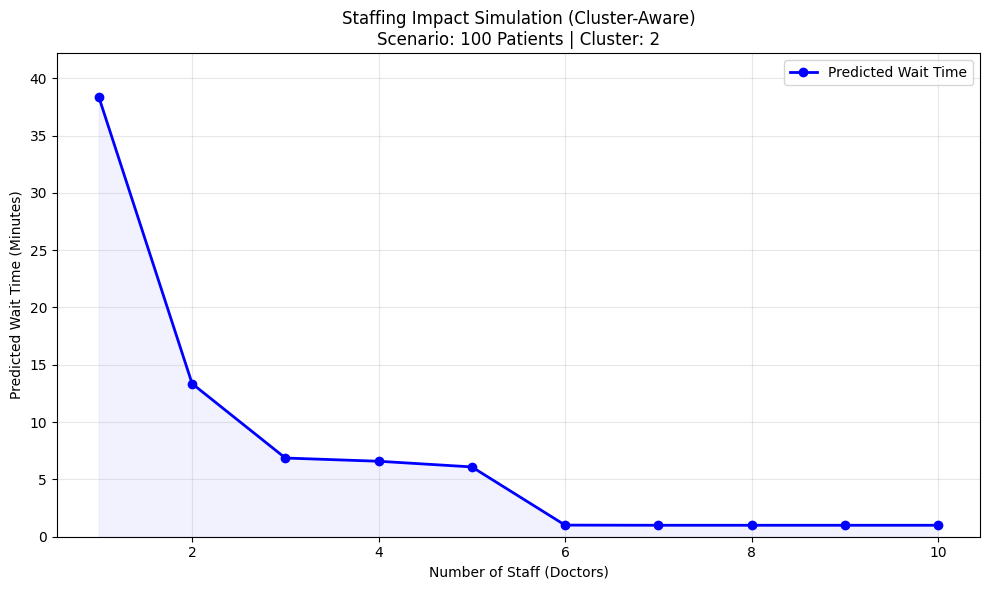


--- Key Drivers of Wait Time ---
1. Historical_Base_Wait (33.03%)
2. District_Batang Kali (7.97%)
3. IsPublicHoliday (4.47%)
4. District_Central KL (3.57%)
5. Cluster_Encoded (3.36%)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

print("🚀 STARTING SIMULATION PHASE (Wait Time Regression with Clusters)...")

# =========================================================
# 1. LOAD DATA & MERGE CLUSTERS
# =========================================================
print("1️⃣ Loading Data & Merging Clusters...")

try:
    # A. Load Daily Operations
    df = pd.read_csv('../data/processed_daily_operations.csv')
    
    # B. Load Static Profiles (The Clusters)
    # We need 'Name' to join, and 'Cluster_Encoded' as the new feature
    static_profiles = pd.read_csv('../data/clinic_static_profiles.csv')
    
    # Merge: Add cluster info to every daily row
    df = pd.merge(df, static_profiles[['Name', 'Cluster_Encoded']], on='Name', how='left')
    
    # Fill missing clusters with a default (e.g., -1) just in case
    df['Cluster_Encoded'] = df['Cluster_Encoded'].fillna(-1)
    
    # Validation
    required_cols = ['Patient_Load_Ratio', 'Load_Stress_Index', 'Historical_Base_Wait', 'Cluster_Encoded']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"❌ Missing features! Expected {required_cols}.")
        
    print(f"   -> Data Loaded. Joined with Clusters. Shape: {df.shape}")

except FileNotFoundError:
    print("❌ Error: Files not found.")
    print("   Make sure 'processed_daily_operations.csv' and 'clinic_static_profiles.csv' exist.")
    exit()

# =========================================================
# 2. DATA PREPARATION
# =========================================================
print("2️⃣ Preparing Data for Training...")

# One-Hot Encoding for categorical regions
df_encoded = pd.get_dummies(df, columns=['State', 'District'], drop_first=True)

# Define Features (X) and Target (y)
# We KEEP 'Cluster_Encoded' but DROP 'Name'
drop_cols = ['Avg_Wait_Time', 'Name', 'Date', 'High_Wait_Risk']
X = df_encoded.drop(columns=drop_cols, errors='ignore')
y = df_encoded['Avg_Wait_Time']

print(f"   -> Features used: {X.shape[1]} columns")

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================
# 3. MODEL TRAINING (With Physics Constraints)
# =========================================================
print("3️⃣ Training XGBoost Regression Model...")

# --- DEFINE MONOTONIC CONSTRAINTS ---
monotone_dic = {}

if 'Staff_Count' in X.columns:
    monotone_dic['Staff_Count'] = -1  # More Staff -> LESS Wait Time

if 'Patient_Load_Ratio' in X.columns:
    monotone_dic['Patient_Load_Ratio'] = 1 # Higher Load Ratio -> MORE Wait Time

if 'Load_Stress_Index' in X.columns:
    monotone_dic['Load_Stress_Index'] = 1 # Higher Stress -> MORE Wait Time

# Create constraint tuple in the exact order of columns
constraints_list = [monotone_dic.get(col, 0) for col in X.columns]

# Train Model
xgb_model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6, 
    n_jobs=-1,
    monotone_constraints=tuple(constraints_list)
)

xgb_model.fit(X_train, y_train)

# =========================================================
# 4. EVALUATION
# =========================================================
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Metrics ---")
print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R2   : {r2:.2f}")

# =========================================================
# 5. SIMULATION (Physics-Informed)
# =========================================================
print("\n5️⃣ Generating Staffing Impact Curve...")

# Scenario Parameters
patient_volume = 100  
staff_range = range(1, 11) 
scenarios = []

# --- Create Baseline Template ---
# Use the average of the training set to create a "Typical Clinic"
template_row = X_train.mean().to_dict()

# Force specific scenario settings
template_row['IsWeekend'] = 0
template_row['IsPublicHoliday'] = 0

# Set Cluster to the most common one (Mode)
common_cluster = df['Cluster_Encoded'].mode()[0]
template_row['Cluster_Encoded'] = common_cluster

# --- Generate Synthetic Data ---
for staff in staff_range:
    row = template_row.copy()
    
    # Calculate Physics
    load_ratio = patient_volume / staff
    stress_index = load_ratio ** 2
    
    # Update Dynamic Values
    row['Total_Daily_Patients'] = patient_volume
    row['Staff_Count'] = staff
    row['Patient_Load_Ratio'] = load_ratio
    row['Load_Stress_Index'] = stress_index
    
    scenarios.append(row)

# Ensure scenario dataframe matches feature order
scenario_df = pd.DataFrame(scenarios)
scenario_df = scenario_df[X_train.columns] # Reorder columns to match training

# 1. Base Prediction (From XGBoost)
raw_predictions = xgb_model.predict(scenario_df)

# 2. APPLY "OVERLOAD PENALTY" (Extrapolation Fix)
overload_threshold = 40 
penalty_factor = 0.5 

overload_penalty = np.where(
    scenario_df['Patient_Load_Ratio'] > overload_threshold,
    (scenario_df['Patient_Load_Ratio'] - overload_threshold) * penalty_factor,
    0
)

# Combine Base + Penalty
adjusted_predictions = raw_predictions + overload_penalty
final_predictions = np.maximum(adjusted_predictions, 1.0)

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(staff_range, final_predictions, marker='o', linestyle='-', color='b', linewidth=2, label='Predicted Wait Time')

# REMOVED: The red 30-min threshold line and the red/green zones

# OPTIONAL: Add a simple light blue shade under the curve for visuals
plt.fill_between(staff_range, 0, final_predictions, color='blue', alpha=0.05)

plt.title(f'Staffing Impact Simulation (Cluster-Aware)\nScenario: {patient_volume} Patients | Cluster: {common_cluster}')
plt.xlabel('Number of Staff (Doctors)')
plt.ylabel('Predicted Wait Time (Minutes)')
plt.ylim(0, max(final_predictions.max() * 1.1, 10)) 
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 6. FEATURE IMPORTANCE
# =========================================================
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n--- Key Drivers of Wait Time ---")
for i in range(5):
    if i < len(indices):
        print(f"{i+1}. {X.columns[indices[i]]} ({importances[indices[i]]:.2%})")

In [16]:
import os
import joblib

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

# 1. Save the XGBoost Regression Model
xgb_model.save_model('../models/xgboost_waittime_simulator.json')

# 2. Save the expected column names (Crucial for Streamlit to format input correctly!)
joblib.dump(list(X_train.columns), '../models/waittime_feature_columns.pkl')

print("\n✅ MODELS SAVED: Wait Time Simulator & Feature Columns extracted to 'models/'")


✅ MODELS SAVED: Wait Time Simulator & Feature Columns extracted to 'models/'


### 📊 Residual Diagnostics

A residual analysis plot is generated to evaluate the **wait-time prediction model** by comparing prediction errors against fitted values.

This diagnostic helps identify potential systematic bias and verifies that the model produces reliable and unbiased wait-time estimates.

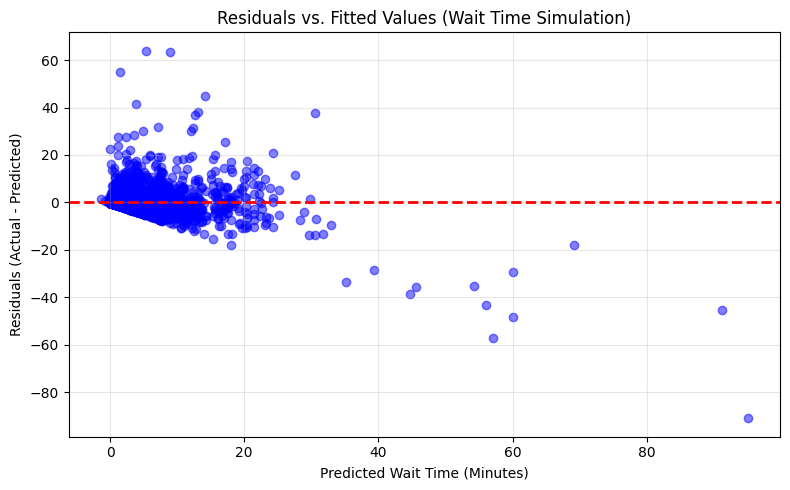

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have y_test (actual) and y_pred (predicted) from your XGBoost model
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Fitted Values (Wait Time Simulation)')
plt.xlabel('Predicted Wait Time (Minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 🚨 Phase 4 — Crisis Alert System (Classification & Threshold Optimization)

This module builds an Early Warning System. While regression models predict exact wait times, operational managers often just need a binary, automated trigger: *Is this clinic at risk of a wait-time crisis (>30 mins) today?*

### 🔹 Imbalance Handling & Classification
Wait-time crises are minority events (imbalanced classes). To ensure the model doesn't just lazily predict "Safe" every time, this `XGBClassifier` calculates and applies dynamic positive class weighting (`scale_pos_weight`) to penalize the model heavily for missing a crisis.

### 🔹 Precision-Recall Threshold Optimization
In healthcare operations, a False Negative (failing to prepare for a crisis) is far more costly than a False Positive (over-preparing). Instead of using the default 0.50 probability threshold, this script analyzes the **Precision-Recall Curve** to find the exact mathematical threshold required to guarantee an **85% Recall rate**—ensuring the vast majority of operational bottlenecks are flagged before they happen.

### 💾 Model Extraction & Deployment
The trained classifier and the custom-calculated decision threshold are exported to the `models/` directory. The Streamlit dashboard will use these files to scan network-wide schedules and instantly flag high-risk clinics with a visual alert.

🚀 STARTING CLASSIFICATION PHASE (Crisis Alert System with Clusters)...
1️⃣ Loading Data & Merging Clusters...
   -> Data Loaded. Joined with Clusters. Shape: (17297, 14)
2️⃣ Preparing Data for Training...
   -> Features used: 74 columns
   -> Data Balance: 13711 Safe vs 126 Danger (Weight: 108.82)
3️⃣ Training XGBoost Classifier...
4️⃣ Optimizing Alert Threshold...
   -> Default Threshold (0.50) Recall: 77.4%
   -> Optimal Threshold (0.368) Recall: 87.1%

--- Final Alert System Results (Threshold >= 0.368) ---
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      3429
           1       0.07      0.87      0.14        31

    accuracy                           0.90      3460
   macro avg       0.54      0.89      0.54      3460
weighted avg       0.99      0.90      0.94      3460

ROC-AUC Score: 0.95


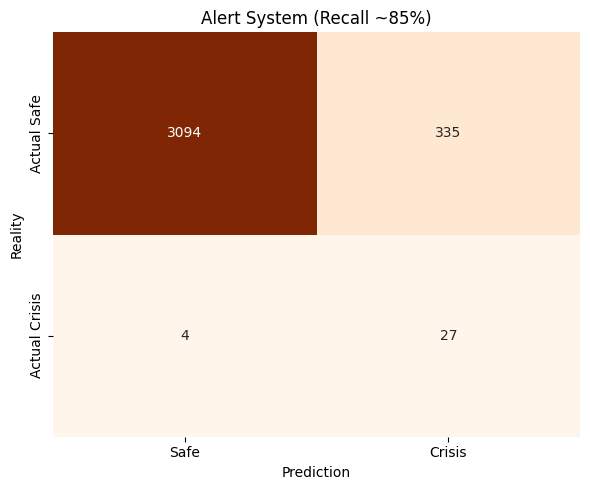

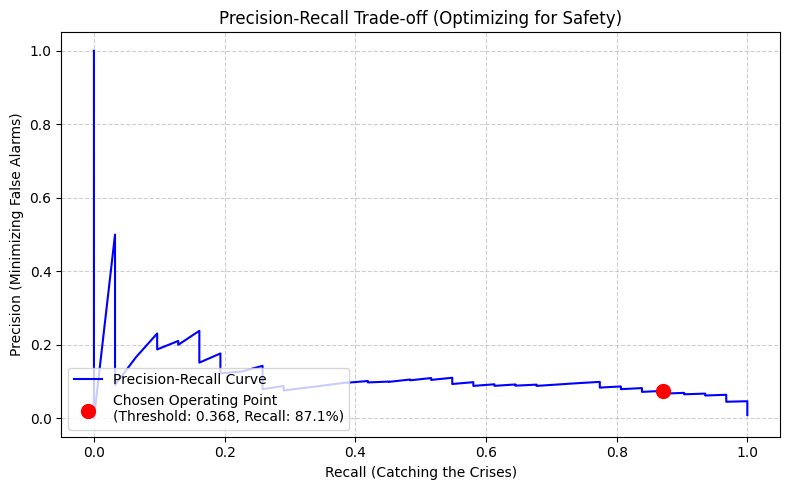

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import warnings

warnings.filterwarnings('ignore')

print("🚀 STARTING CLASSIFICATION PHASE (Crisis Alert System with Clusters)...")

# =========================================================
# 1. LOAD DATA & MERGE CLUSTERS
# =========================================================
print("1️⃣ Loading Data & Merging Clusters...")

try:
    # A. Load Daily Operations
    df = pd.read_csv('../data/processed_daily_operations.csv')
    
    # B. Load Static Profiles (The Clusters)
    static_profiles = pd.read_csv('../data/clinic_static_profiles.csv')
    
    # Merge: Add cluster info to every daily row
    df = pd.merge(df, static_profiles[['Name', 'Cluster_Encoded']], on='Name', how='left')
    
    # Fill missing clusters with a default (e.g., -1)
    df['Cluster_Encoded'] = df['Cluster_Encoded'].fillna(-1)
    
    # Validation
    required_cols = ['Load_Stress_Index', 'Historical_Base_Wait', 'High_Wait_Risk', 'Cluster_Encoded']
    if not all(col in df.columns for col in required_cols):
        # Fallback: Create target if missing
        if 'High_Wait_Risk' not in df.columns and 'Avg_Wait_Time' in df.columns:
             print("   -> 'High_Wait_Risk' missing. Creating target from Avg_Wait_Time > 30...")
             df['High_Wait_Risk'] = (df['Avg_Wait_Time'] > 30).astype(int)
        else:
             raise ValueError(f"❌ Missing features! Expected {required_cols}.")
             
    print(f"   -> Data Loaded. Joined with Clusters. Shape: {df.shape}")

except FileNotFoundError:
    print("❌ Error: Files not found.")
    exit()

# =========================================================
# 2. DATA PREPARATION (One-Hot Encoding)
# =========================================================
print("2️⃣ Preparing Data for Training...")

# One-Hot Encoding for State & District (Better than Label Encoding)
df_encoded = pd.get_dummies(df, columns=['State', 'District'], drop_first=True)

# Define Features (X) and Target (y)
# We KEEP 'Cluster_Encoded' but DROP identifiers
drop_cols = ['High_Wait_Risk', 'Name', 'Date', 'Avg_Wait_Time']
X = df_encoded.drop(columns=drop_cols, errors='ignore')
y = df_encoded['High_Wait_Risk']

print(f"   -> Features used: {X.shape[1]} columns")

# Split Data (Stratify is important for imbalanced risk)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calculate Scale Pos Weight (Crucial for Imbalance)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count if pos_count > 0 else 1.0

print(f"   -> Data Balance: {neg_count} Safe vs {pos_count} Danger (Weight: {scale_weight:.2f})")

# =========================================================
# 3. TRAIN XGBOOST CLASSIFIER
# =========================================================
print("3️⃣ Training XGBoost Classifier...")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_weight, 
    eval_metric='auc',
    use_label_encoder=False,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# =========================================================
# 4. THRESHOLD OPTIMIZATION (Fine Tuning)
# =========================================================
print("4️⃣ Optimizing Alert Threshold...")

# Get probabilities (confidence scores)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate Precision & Recall for ALL possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# STRATEGY: Prioritize Recall (Safety). Catch at least 85% of crises.
desired_recall = 0.85

valid_indices = np.where(recalls >= desired_recall)[0]
if len(valid_indices) > 0:
    optimal_idx = valid_indices[-1]
    optimal_threshold = thresholds[optimal_idx]
else:
    optimal_threshold = 0.50 

default_recall = (y_prob >= 0.50).astype(int).dot(y_test) / y_test.sum() if y_test.sum() > 0 else 0
optimal_recall = recalls[optimal_idx] if len(valid_indices) > 0 else 0

print(f"   -> Default Threshold (0.50) Recall: {default_recall:.1%}")
print(f"   -> Optimal Threshold ({optimal_threshold:.3f}) Recall: {optimal_recall:.1%}")

# =========================================================
# 5. FINAL EVALUATION
# =========================================================
y_pred_optimized = (y_prob >= optimal_threshold).astype(int)

print(f"\n--- Final Alert System Results (Threshold >= {optimal_threshold:.3f}) ---")
print(classification_report(y_test, y_pred_optimized))
try:
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2f}")
except:
    print("ROC-AUC Score: N/A")

# =========================================================
# 6. VISUALIZATION
# =========================================================
# Plot 1: Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Safe', 'Crisis'],
            yticklabels=['Actual Safe', 'Actual Crisis'])
plt.title(f'Alert System (Recall ~{desired_recall:.0%})')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.tight_layout()
plt.show()

# Plot 2: Precision-Recall Curve
plt.figure(figsize=(8, 5))
# Plot the main curve
plt.plot(recalls, precisions, color='blue', label='Precision-Recall Curve')

# Highlight the exact spot you chose (The Optimal Threshold)
optimal_precision = precisions[optimal_idx]
plt.scatter(optimal_recall, optimal_precision, color='red', s=100, zorder=5, 
            label=f'Chosen Operating Point\n(Threshold: {optimal_threshold:.3f}, Recall: {optimal_recall:.1%})')

# Add labels and formatting
plt.title('Precision-Recall Trade-off (Optimizing for Safety)')
plt.xlabel('Recall (Catching the Crises)')
plt.ylabel('Precision (Minimizing False Alarms)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
import os
import joblib

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

# 1. Save the XGBoost Classifier
xgb_model.save_model('../models/xgboost_crisis_classifier.json')

# 2. Save the features AND the custom threshold together in a dictionary
classifier_metadata = {
    'features': list(X_train.columns),
    'optimal_threshold': float(optimal_threshold)
}
joblib.dump(classifier_metadata, '../models/classifier_metadata.pkl')

print("\n✅ MODELS SAVED: Crisis Classifier & Metadata (Threshold + Columns) extracted to 'models/'")


✅ MODELS SAVED: Crisis Classifier & Metadata (Threshold + Columns) extracted to 'models/'


# 🚀 Phase 5 — The Master Pipeline (Future Inference & Triage)

This final module acts as the "brain" of the entire system, combining all previous unsupervised and supervised models into a single, automated, end-to-end batch prediction pipeline.

### 🔀 Intelligent Hybrid Routing
The script automatically evaluates the data maturity of every clinic in the network. 
* **Established Clinics (>14 days data):** Routed through the Master Global Volume Forecaster.
* **New Clinics (Cold Starts):** Automatically routed through the Cluster-Aware Transfer Learning pipeline to receive micro-adjustments from baseline models.

### ⚙️ Downstream Physics & Triage
Once the patient volume is forecasted for the next 7 days, the script passes those predictions down the assembly line:
1. It calculates the **Load Stress Index** based on average staffing.
2. It feeds the stress metrics into the **Wait Time Simulator** (Regression).
3. It passes the wait times into the **Crisis Alert System** (Classification).

### 📊 Deployment Output
The pipeline ultimately classifies every future day as a *Normal Day*, *Busy Day*, or *Crisis Day*. It outputs the entire network's 7-day outlook into `next_week_forecast_final.csv`, which serves as the direct data source powering the live Streamlit dashboard.

In [20]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor, XGBClassifier
import warnings
import os

warnings.filterwarnings('ignore')

print("🚀 STARTING FINAL MASTER PIPELINE (Hybrid Transfer Learning + Forecasting)...")

# ---------------------------------------------------------
# 🔧 HYBRID CONFIGURATION
# ---------------------------------------------------------
HISTORICAL_THRESHOLD_HOURS = 336 # 14 days of history required for Global Model

# =========================================================
# 1. LOAD & PREPARE DATA
# =========================================================
print("1️⃣ Loading Data & Static Profiles...")

# --- A. LOAD CLUSTER PROFILES (STRATEGIC DNA) ---
try:
    static_profiles = pd.read_csv('../data/clinic_static_profiles.csv')
    visual_clusters = pd.read_csv('../data/clinic_clusters_final.csv') # Need this for the .json filenames
    
    # Merge the text label into the static profiles for easy access
    if 'Cluster_Label' in visual_clusters.columns:
        static_profiles = pd.merge(static_profiles, visual_clusters[['Name', 'Cluster_Label']], on='Name', how='left')
    
    print(f"   -> Loaded Static Profiles for {len(static_profiles)} clinics")
except FileNotFoundError:
    print("❌ Error: Cluster profile files not found. Run Clustering script first.")
    exit()

# --- B. HOURLY DATA (For Volume Forecast) ---
try:
    df_hourly = pd.read_csv('../data/processed_hourly_demand.csv')
    df_hourly['Date'] = pd.to_datetime(df_hourly['Date'])
    
    model_data = pd.merge(df_hourly, static_profiles[['Name', 'Cluster_Encoded', 'Cluster_Label']], on='Name', how='left')
    model_data['Cluster_Encoded'] = model_data['Cluster_Encoded'].fillna(-1) 
    model_data = model_data.reset_index(drop=True)
    print(f"   -> Loaded Hourly Data: {len(model_data)} rows")
except FileNotFoundError:
    print("❌ Error: 'processed_hourly_demand.csv' not found.")
    exit()

# --- C. DAILY DATA (For Wait Time & Risk) ---
try:
    df_daily = pd.read_csv('../data/processed_daily_operations.csv')
    df_daily = pd.merge(df_daily, static_profiles[['Name', 'Cluster_Encoded']], on='Name', how='left')
    df_daily['Cluster_Encoded'] = df_daily['Cluster_Encoded'].fillna(-1)

    if 'High_Wait_Risk' not in df_daily.columns:
        df_daily['High_Wait_Risk'] = (df_daily['Avg_Wait_Time'] > 30).astype(int)
        
    print(f"   -> Loaded Daily Data: {len(df_daily)} rows")
except FileNotFoundError:
    print("❌ Error: 'processed_daily_operations.csv' not found.")
    exit()

# =========================================================
# 2. DEFINE FEATURES
# =========================================================
print("2️⃣ Defining Feature Sets...")

# Hybrid Routing Features
global_features = ['Hour', 'IsWeekend', 'IsPublicHoliday', 'Name_Encoded', 'Cluster_Encoded', 'Lag_24', 'Lag_168', 'Rolling_Mean_168']
tl_features = ['Hour', 'IsWeekend', 'IsPublicHoliday', 'Lag_24', 'Lag_168', 'Rolling_Mean_168']
target_vol = 'Calculated_Hourly_Demand'

# Wait Time & Risk Features
features_wait = [
    'Total_Daily_Patients', 'Staff_Count', 
    'Patient_Load_Ratio', 'Load_Stress_Index', 
    'Historical_Base_Wait', 'Cluster_Encoded', 
    'IsWeekend', 'IsPublicHoliday'
]

# =========================================================
# 3. TRAIN MASTER MODELS (Global + Downstream)
# =========================================================

# --- A. MASTER GLOBAL VOLUME MODEL (For Established Clinics) ---
print("3️⃣ Training Master Global Volume Forecaster (XGBoost)...")
global_model = XGBRegressor(n_estimators=250, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, n_jobs=-1, random_state=42)
global_model.fit(model_data[global_features], model_data[target_vol])

# --- B. WAIT TIME MODEL ---
print("4️⃣ Training Wait Time Estimator (XGBoost)...")
xgb_wait = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=42)
xgb_wait.fit(df_daily[features_wait], df_daily['Avg_Wait_Time'])

# --- C. RISK MODEL ---
print("5️⃣ Training Crisis Alert System (Classifier)...")
scale_pos_weight = (df_daily['High_Wait_Risk'] == 0).sum() / (df_daily['High_Wait_Risk'] == 1).sum()
if np.isinf(scale_pos_weight) or np.isnan(scale_pos_weight): scale_pos_weight = 1.0

xgb_risk = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, eval_metric='auc', random_state=42)
xgb_risk.fit(df_daily[features_wait], df_daily['High_Wait_Risk'])

# =========================================================
# 4. GENERATE FUTURE GRID 
# =========================================================
print("\n🔮 BUILDING FUTURE CALENDAR GRID...")

network_latest_date = model_data['Date'].max()
future_input_list = []

for clinic in model_data['Name'].unique():
    c_data = model_data[model_data['Name'] == clinic]
    if len(c_data) == 0: continue
    
    last_known_date = c_data['Date'].max()
    
    # Check for stale data
    days_behind = (network_latest_date - last_known_date).days
    status_msg = f"STALE DATA ({days_behind} days lag)" if days_behind > 3 else "Live"
        
    start_window = last_known_date - pd.Timedelta(days=6)
    perfect_range = pd.date_range(start=start_window, end=last_known_date, freq='D')
    window_data = c_data[(c_data['Date'] >= start_window) & (c_data['Date'] <= last_known_date)].copy()
    
    # Sparse Data Fix
    unique_days = window_data['Date'].nunique()
    c_name_enc = c_data['Name_Encoded'].iloc[0]
    c_clust_enc = c_data['Cluster_Encoded'].iloc[0] 
    
    if unique_days < 7:
        full_grid = []
        for d in perfect_range:
            for h in range(24): 
                full_grid.append({
                    'Date': d, 'Hour': h, 'Name': clinic,
                    'Name_Encoded': c_name_enc, 'Cluster_Encoded': c_clust_enc
                })
        
        df_grid = pd.DataFrame(full_grid)
        merged = pd.merge(df_grid, window_data, on=['Date', 'Hour', 'Name', 'Name_Encoded', 'Cluster_Encoded'], how='left')
        merged['Calculated_Hourly_Demand'] = merged['Calculated_Hourly_Demand'].fillna(0)
        for col in ['Lag_24', 'Lag_168', 'Rolling_Mean_168']:
            if col in merged.columns: merged[col] = merged[col].fillna(0)
        window_data = merged

    # Shift Dates Forward
    window_data['Date'] = window_data['Date'] + pd.Timedelta(days=7)
    window_data['Data_Quality_Status'] = status_msg
    future_input_list.append(window_data)

future_input = pd.concat(future_input_list, ignore_index=True)

# Add Calendar Features for the Future Grid
future_input['IsWeekend'] = future_input['Date'].dt.dayofweek.isin([5, 6]).astype(int)
future_input['IsPublicHoliday'] = 0 

# =========================================================
# 5. HYBRID ROUTING PREDICTION (The Upgrade!)
# =========================================================
print("\n🔀 RUNNING HYBRID ROUTING (Predicting Volume)...")

predicted_future_list = []

for clinic in model_data['Name'].unique():
    clinic_hist = model_data[model_data['Name'] == clinic].sort_values('Date')
    clinic_future = future_input[future_input['Name'] == clinic].copy()
    
    if len(clinic_future) == 0: continue
        
    if len(clinic_hist) >= HISTORICAL_THRESHOLD_HOURS:
        # PATH A: Established Clinic -> Global Model
        preds = global_model.predict(clinic_future[global_features])
    else:
        # PATH B: Cold Start -> Transfer Learning
        cluster_label = static_profiles[static_profiles['Name'] == clinic]['Cluster_Label'].iloc[0]
        safe_cluster_name = str(cluster_label).replace(' ', '_').lower()
        base_model_path = f"base_models/xgb_base_{safe_cluster_name}.json"
        
        # Gentle fine-tuning
        tl_model = XGBRegressor(n_estimators=20, learning_rate=0.05, max_depth=3, random_state=42)
        if os.path.exists(base_model_path):
            tl_model.fit(clinic_hist[tl_features], clinic_hist[target_vol], xgb_model=base_model_path)
        else:
            tl_model.fit(clinic_hist[tl_features], clinic_hist[target_vol])
            
        preds = tl_model.predict(clinic_future[tl_features])
        
    clinic_future['Predicted_Hourly_Demand'] = np.clip(preds, 0, None)
    predicted_future_list.append(clinic_future)

future_input_scored = pd.concat(predicted_future_list)

# =========================================================
# 6. DOWNSTREAM PROCESSING (Wait Time & Triage)
# =========================================================
print("⏳ Calculating Downstream Impacts (Wait Times & Risk)...")

# Aggregate to Daily
future_daily = future_input_scored.groupby(['Name', 'Name_Encoded', 'Cluster_Encoded', 'Date', 'IsWeekend', 'IsPublicHoliday', 'Data_Quality_Status']).agg({
    'Predicted_Hourly_Demand': 'sum'
}).reset_index()
future_daily.rename(columns={'Predicted_Hourly_Demand': 'Total_Daily_Patients'}, inplace=True)
future_daily['Total_Daily_Patients'] = future_daily['Total_Daily_Patients'].round(0).astype(int)

# Add Staff & Efficiency
avg_staff = df_daily.groupby('Name')['Staff_Count'].mean().round(0).replace(0, 1).reset_index()
future_daily = pd.merge(future_daily, avg_staff, on='Name', how='left')

clinic_eff_map = df_daily[['Name', 'Historical_Base_Wait']].drop_duplicates()
future_daily = pd.merge(future_daily, clinic_eff_map, on='Name', how='left')
future_daily['Historical_Base_Wait'].fillna(df_daily['Historical_Base_Wait'].mean(), inplace=True)

# Calculate Physics
future_daily['Patient_Load_Ratio'] = future_daily['Total_Daily_Patients'] / future_daily['Staff_Count']
future_daily['Load_Stress_Index'] = future_daily['Patient_Load_Ratio'] ** 2

# Predict Wait Time
raw_wait_preds = xgb_wait.predict(future_daily[features_wait])
future_daily['Predicted_Wait_Time'] = np.where(future_daily['Patient_Load_Ratio'] < 1.0, 1.0, raw_wait_preds)
future_daily['Predicted_Wait_Time'] = future_daily['Predicted_Wait_Time'].clip(lower=1)

# Predict Risk
future_daily['Predicted_Risk_Prob'] = xgb_risk.predict_proba(future_daily[features_wait])[:, 1]
future_daily['Crisis_Alert'] = (future_daily['Predicted_Risk_Prob'] > 0.60).astype(int)

# Dynamic Triage
def assign_day_status(row):
    if row['Predicted_Wait_Time'] > 30: return 'Crisis Day'
    elif row['Predicted_Wait_Time'] > 15 or row['Crisis_Alert'] == 1: return 'Busy Day'
    else: return 'Normal Day'

future_daily['Day_Status'] = future_daily.apply(assign_day_status, axis=1)

# Format Visual Clusters for Dashboard
if 'Cluster_Label' in static_profiles.columns:
    visual_map = static_profiles[['Name', 'Cluster_Label']].rename(columns={'Cluster_Label': 'Cluster_Name'})
    future_daily = pd.merge(future_daily, visual_map, on='Name', how='left')
else:
    future_daily['Cluster_Name'] = 'Unknown'

# =========================================================
# 7. SAVE FINAL REPORT
# =========================================================
output_cols = ['Date', 'Name', 'Total_Daily_Patients', 'Staff_Count', 
               'Predicted_Wait_Time', 'Predicted_Risk_Prob', 
               'Crisis_Alert', 'Day_Status', 'Cluster_Name', 'Data_Quality_Status']

future_daily[output_cols].to_csv('../data/next_week_forecast_final.csv', index=False)

print("\n--- FORECAST SUMMARY ---")
print(future_daily['Day_Status'].value_counts())
stale_count = future_daily['Data_Quality_Status'].astype(str).str.contains('STALE').sum()
if stale_count > 0:
    print(f"⚠️ Warning: {stale_count} forecast rows are based on STALE data.")
print(f"Total Forecast Rows: {len(future_daily)}")
print("\n✅ Forecast saved to 'next_week_forecast_final.csv'")

🚀 STARTING FINAL MASTER PIPELINE (Hybrid Transfer Learning + Forecasting)...
1️⃣ Loading Data & Static Profiles...
   -> Loaded Static Profiles for 98 clinics
   -> Loaded Hourly Data: 200903 rows
   -> Loaded Daily Data: 17297 rows
2️⃣ Defining Feature Sets...
3️⃣ Training Master Global Volume Forecaster (XGBoost)...
4️⃣ Training Wait Time Estimator (XGBoost)...
5️⃣ Training Crisis Alert System (Classifier)...

🔮 BUILDING FUTURE CALENDAR GRID...

🔀 RUNNING HYBRID ROUTING (Predicting Volume)...
⏳ Calculating Downstream Impacts (Wait Times & Risk)...

--- FORECAST SUMMARY ---
Day_Status
Normal Day    653
Busy Day       20
Crisis Day     13
Name: count, dtype: int64
⚠️ Warning: 14 forecast rows are based on STALE data.
Total Forecast Rows: 686

✅ Forecast saved to 'next_week_forecast_final.csv'
